# Modelo predictivo y exploratorio para análisis de estructuras reticulares parametrizadas

**Iteración 3 — Sección 1 + Sección 2A**

Esta iteración optimiza el notebook con base en la revisión de resultados de la iteración 2:

- La **Sección 1** queda enfocada en carga, preparación conservadora, variables derivadas y dataframes por familia, sin gráficos.
- La **Sección 2A** concentra todo el EDA y las visualizaciones.
- Se agregan ratios CAD adimensionales por familia para capturar relaciones físicas de escala.
- Se simplifican gráficos redundantes: pairplots quedan como opcionales y los gráficos principales son focalizados.
- Se agregan resúmenes de Pareto por geometría y conclusiones automáticas del EDA.

# 1. Problema y datos

El proyecto analiza estructuras reticulares o *lattice structures* parametrizadas generadas en SolidWorks. Cada fila representa una combinación CAD. Algunas reconstruyen correctamente y otras fallan. Por tanto, se plantean dos líneas principales de modelado:

1. **Clasificación de viabilidad geométrica:** predecir `rebuild_ok_bin`.
2. **Regresión de propiedades físicas:** predecir propiedades como `volume_m3`, `surface_area_m2` y `envelope_volume_m3` solo para geometrías viables.

Decisiones metodológicas:

- Las fallas no se eliminan, porque son necesarias para clasificación.
- Las salidas físicas faltantes en fallas son esperadas.
- Solo se eliminan duplicados estrictos: mismas entradas CAD y mismas salidas.
- Se crean dataframes generales por familia: `df_bcc`, `df_exp`, `df_kelvin`, `df_schwarz`.
- Las masas se conservan para análisis industrial, pero no se usarán como features principales porque dependen de `volume_m3`.

In [1]:
# ============================================================
# 1.1 Configuración inicial
# ============================================================

!pip install -q openpyxl

import os
import io
import hashlib
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid")
except ImportError:
    sns = None

from IPython.display import display

pd.set_option("display.max_columns", 140)
pd.set_option("display.max_colwidth", 150)
pd.set_option("display.float_format", "{:,.6f}".format)

RANDOM_STATE = 42
RUN_PAIRPLOTS = False  # Cambiar a True solo si quieres gráficos diagnósticos pesados

os.makedirs("data/processed", exist_ok=True)
os.makedirs("outputs/figures", exist_ok=True)
os.makedirs("outputs/tables", exist_ok=True)

In [2]:
# ============================================================
# 1.2 Configuración del repositorio GitHub
# ============================================================

GITHUB_USER = "diego-rivera-eng"
REPO_NAME = "lattice_strucures_cad-ml"
BRANCH = "main"
BASE_RAW_URL = f"https://raw.githubusercontent.com/{GITHUB_USER}/{REPO_NAME}/{BRANCH}/data/raw"

DATA_FILES = {
    "BCC": ["bcc_batch_step_resultsA.xlsx", "bcc_batch_step_resultsB.xlsx"],
    "EXP": ["exp_batch_step_results.xlsx"],
    "KELVIN": ["kelvin_batch_step_results.xlsx"],
    "SCHWARZ": ["schwarz_batch_step_results.xlsx"]
}

print(BASE_RAW_URL)

https://raw.githubusercontent.com/diego-rivera-eng/lattice_strucures_cad-ml/main/data/raw


In [3]:
# ============================================================
# 1.3 Carga reproducible desde GitHub
# ============================================================

def read_excel_from_github(url):
    response = requests.get(url)
    if response.status_code != 200:
        raise ValueError(f"No se pudo leer el archivo. URL={url}, status={response.status_code}")
    return pd.read_excel(io.BytesIO(response.content))


def load_lattice_datasets(base_url, data_files):
    frames = []
    for geometry, files in data_files.items():
        for file_name in files:
            url = f"{base_url}/{file_name}"
            print(f"Cargando {geometry}: {file_name}")
            df_temp = read_excel_from_github(url)
            df_temp["geometry"] = geometry
            df_temp["source_file"] = file_name
            frames.append(df_temp)
    return pd.concat(frames, ignore_index=True)


df_all_raw = load_lattice_datasets(BASE_RAW_URL, DATA_FILES)
print(f"Filas: {df_all_raw.shape[0]:,}")
print(f"Columnas: {df_all_raw.shape[1]:,}")
display(df_all_raw.head())

Cargando BCC: bcc_batch_step_resultsA.xlsx
Cargando BCC: bcc_batch_step_resultsB.xlsx
Cargando EXP: exp_batch_step_results.xlsx
Cargando KELVIN: kelvin_batch_step_results.xlsx
Cargando SCHWARZ: schwarz_batch_step_results.xlsx
Filas: 3,050
Columnas: 35


,run_id,timestamp,status,error_message,rebuild_ok,solidworks_status,D_toro,d_wire,n_arms,n_radial,envelope_volume_m3,volume_m3,surface_area_m2,plastic_mass_kg,steel_mass_kg,elapsed_s,screenshot_path,open_errors,open_warnings,geometry,source_file,t,square,excentricity,height,screenshot_status,screenshot_error,cell_size,alpha,wire_diameter,beta,theta,n_circular,node_diameter,thick
0,1,2026-05-29T22:07:49,OK,NaN,True,0.000000,100.000000,5.000000,3.000000,3.000000,0.028373,0.001597,1.197371,1.628838,12.615512,12.173479,C:\Users\diego\Desktop\PROYECTO_FINAL_CURSO_3\data\screenshots\run_001_D_toro_100_d_wire_5_n_arms_3_n_radial_3.bmp,0,0,BCC,bcc_batch_step_resultsA.xlsx,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,2026-05-29T22:08:02,OK,NaN,True,0.000000,100.000000,5.000000,3.000000,4.000000,0.028373,0.001581,1.187753,1.612138,12.486167,9.219471,NaN,0,0,BCC,bcc_batch_step_resultsA.xlsx,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,2026-05-29T22:08:11,OK,NaN,True,0.000000,100.000000,5.000000,3.000000,5.000000,0.028373,0.001867,1.400279,1.904013,14.746770,12.855956,NaN,0,0,BCC,bcc_batch_step_resultsA.xlsx,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,2026-05-29T22:08:24,OK,NaN,True,0.000000,100.000000,5.000000,3.000000,6.000000,0.028373,0.001763,1.321948,1.797943,13.925243,11.512582,NaN,0,0,BCC,bcc_batch_step_resultsA.xlsx,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,2026-05-29T22:08:36,OK,NaN,True,0.000000,100.000000,5.000000,4.000000,3.000000,0.028373,0.001363,1.036231,1.390155,10.766890,8.796545,NaN,0,0,BCC,bcc_batch_step_resultsA.xlsx,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# ============================================================
# 1.4 Variables del proyecto
# ============================================================

INPUT_COLS_BY_GEOMETRY_BASE = {
    "BCC": ["D_toro", "d_wire", "n_arms", "n_radial"],
    "EXP": ["t", "square", "excentricity", "height"],
    "KELVIN": ["cell_size", "alpha", "wire_diameter", "beta", "theta", "n_circular"],
    "SCHWARZ": ["cell_size", "node_diameter", "thick"]
}

# Alias para compatibilidad
INPUT_COLS_BY_GEOMETRY = INPUT_COLS_BY_GEOMETRY_BASE.copy()

PHYSICAL_OUTPUTS = [
    "envelope_volume_m3", "volume_m3", "surface_area_m2",
    "plastic_mass_kg", "steel_mass_kg", "elapsed_s"
]

MAIN_REGRESSION_TARGETS = ["volume_m3", "surface_area_m2", "envelope_volume_m3", "elapsed_s"]
BINARY_OUTPUT = "rebuild_ok_bin"

DERIVED_PERFORMANCE_COLS = [
    "relative_density", "porosity", "surface_to_volume_ratio",
    "surface_to_envelope_volume_ratio", "surface_to_plastic_mass",
    "surface_to_steel_mass", "plastic_mass_per_envelope_volume",
    "steel_mass_per_envelope_volume"
]

CAD_DERIVED_INPUTS_BY_GEOMETRY = {
    "BCC": ["d_wire_to_D_toro"],
    "EXP": ["height_to_square"],
    "KELVIN": ["wire_diameter_to_cell_size"],
    "SCHWARZ": ["thick_to_cell_size", "node_diameter_to_cell_size"]
}

for geometry, cols in INPUT_COLS_BY_GEOMETRY_BASE.items():
    print(f"{geometry}: {cols}")

BCC: ['D_toro', 'd_wire', 'n_arms', 'n_radial']
EXP: ['t', 'square', 'excentricity', 'height']
KELVIN: ['cell_size', 'alpha', 'wire_diameter', 'beta', 'theta', 'n_circular']
SCHWARZ: ['cell_size', 'node_diameter', 'thick']


In [5]:
# ============================================================
# 1.5 Normalización de rebuild_ok y conversiones numéricas
# ============================================================

df_all = df_all_raw.copy()

df_all["status_norm"] = (
    df_all["status"].astype(str).str.strip().str.upper()
    if "status" in df_all.columns else np.nan
)


def normalize_rebuild_ok(value):
    if pd.isna(value):
        return np.nan
    if isinstance(value, bool):
        return int(value)
    value_str = str(value).strip().lower()
    true_values = ["true", "1", "yes", "y", "si", "sí", "ok", "success"]
    false_values = ["false", "0", "no", "n", "fail", "failed", "error"]
    if value_str in true_values:
        return 1
    if value_str in false_values:
        return 0
    return np.nan


df_all[BINARY_OUTPUT] = df_all["rebuild_ok"].apply(normalize_rebuild_ok)

mask_unknown = df_all[BINARY_OUTPUT].isna()
df_all.loc[mask_unknown & df_all["status_norm"].isin(["OK", "SUCCESS"]), BINARY_OUTPUT] = 1
df_all.loc[mask_unknown & df_all["status_norm"].str.contains("FAIL|FAILED|ERROR|ERR", na=False), BINARY_OUTPUT] = 0

df_all["failure_bin"] = np.where(df_all[BINARY_OUTPUT].notna(), 1 - df_all[BINARY_OUTPUT].astype(float), np.nan)

all_input_cols_base = sorted(set(sum(INPUT_COLS_BY_GEOMETRY_BASE.values(), [])))
numeric_candidate_cols = all_input_cols_base + PHYSICAL_OUTPUTS + ["solidworks_status", "open_errors", "open_warnings"]

for col in numeric_candidate_cols:
    if col in df_all.columns:
        df_all[col] = pd.to_numeric(df_all[col], errors="coerce")

print("Distribución global de rebuild_ok_bin:")
display(df_all[BINARY_OUTPUT].value_counts(dropna=False).rename("count").to_frame())

Distribución global de rebuild_ok_bin:


,count
rebuild_ok_bin,
1,2711
0,339


## 1.6 Identificador de diseño paramétrico

El `design_group_id` identifica combinaciones únicas de parámetros CAD dentro de cada familia. No identifica una fila del Excel, sino un diseño paramétrico. Será útil en modelado para evitar que el mismo diseño aparezca a la vez en entrenamiento y prueba.

In [6]:
# ============================================================
# 1.6 Identificador de diseño paramétrico
# ============================================================

def make_design_group_id(row, input_cols_by_geometry):
    geometry = row["geometry"]
    parts = [f"geometry={geometry}"]
    for col in input_cols_by_geometry[geometry]:
        parts.append(f"{col}={row[col] if col in row.index else np.nan}")
    digest = hashlib.md5("|".join(parts).encode("utf-8")).hexdigest()[:12]
    return f"{geometry}_{digest}"


df_all["design_group_id"] = df_all.apply(make_design_group_id, axis=1, input_cols_by_geometry=INPUT_COLS_BY_GEOMETRY_BASE)

design_group_summary = (
    df_all.groupby("geometry")
    .agg(rows=("geometry", "size"), unique_design_groups=("design_group_id", "nunique"))
    .reset_index()
)

display(design_group_summary)

,geometry,rows,unique_design_groups
0,BCC,512,496
1,EXP,1080,1080
2,KELVIN,648,648
3,SCHWARZ,810,810


## 1.7 Deduplicación estricta

Solo se eliminan registros con la misma familia, las mismas variables de entrada CAD y las mismas variables de salida. Si dos corridas tienen las mismas entradas pero salidas ligeramente diferentes, se conservan y se reportan.

In [7]:
# ============================================================
# 1.7 Eliminación de duplicados estrictos por familia
# ============================================================

OUTPUT_COLS_FOR_DUPLICATES = [BINARY_OUTPUT] + [c for c in PHYSICAL_OUTPUTS if c in df_all.columns]


def remove_strict_duplicates(df, geometry, input_cols, output_cols):
    df_family = df[df["geometry"] == geometry].copy()
    duplicate_key = input_cols + [c for c in output_cols if c in df_family.columns]

    n_before = len(df_family)
    df_family_clean = df_family.drop_duplicates(subset=duplicate_key, keep="first").copy()
    n_after = len(df_family_clean)

    repeated_inputs = (
        df_family_clean.groupby(input_cols, dropna=False)
        .size().reset_index(name="n_records_same_inputs")
        .query("n_records_same_inputs > 1")
        .sort_values("n_records_same_inputs", ascending=False)
    )

    report = {
        "geometry": geometry,
        "rows_before": n_before,
        "strict_duplicates_removed": n_before - n_after,
        "rows_after": n_after,
        "same_inputs_different_outputs_cases": len(repeated_inputs)
    }
    return df_family_clean, report, repeated_inputs


family_dfs = {}
duplicate_reports = []
same_input_reports = {}

for geometry, input_cols in INPUT_COLS_BY_GEOMETRY_BASE.items():
    df_family_clean, report, repeated_inputs = remove_strict_duplicates(df_all, geometry, input_cols, OUTPUT_COLS_FOR_DUPLICATES)
    family_dfs[geometry] = df_family_clean
    duplicate_reports.append(report)
    same_input_reports[geometry] = repeated_inputs

duplicate_report_df = pd.DataFrame(duplicate_reports)
display(duplicate_report_df)

,geometry,rows_before,strict_duplicates_removed,rows_after,same_inputs_different_outputs_cases
0,BCC,512,0,512,16
1,EXP,1080,0,1080,0
2,KELVIN,648,0,648,0
3,SCHWARZ,810,0,810,0


In [8]:
# ============================================================
# 1.8 Feature engineering físico y CAD adimensional
# ============================================================

def safe_divide(numerator, denominator):
    numerator = pd.to_numeric(numerator, errors="coerce")
    denominator = pd.to_numeric(denominator, errors="coerce")
    valid = numerator.notna() & denominator.notna() & np.isfinite(numerator) & np.isfinite(denominator) & (denominator > 0)
    result = pd.Series(np.nan, index=numerator.index, dtype=float)
    result.loc[valid] = numerator.loc[valid] / denominator.loc[valid]
    return result


def add_physical_performance_features(df):
    df = df.copy()
    required = ["volume_m3", "envelope_volume_m3", "surface_area_m2", "plastic_mass_kg", "steel_mass_kg"]
    if not set(required).issubset(df.columns):
        return df
    df["relative_density"] = safe_divide(df["volume_m3"], df["envelope_volume_m3"])
    df["porosity"] = 1 - df["relative_density"]
    df["surface_to_volume_ratio"] = safe_divide(df["surface_area_m2"], df["volume_m3"])
    df["surface_to_envelope_volume_ratio"] = safe_divide(df["surface_area_m2"], df["envelope_volume_m3"])
    df["surface_to_plastic_mass"] = safe_divide(df["surface_area_m2"], df["plastic_mass_kg"])
    df["surface_to_steel_mass"] = safe_divide(df["surface_area_m2"], df["steel_mass_kg"])
    df["plastic_mass_per_envelope_volume"] = safe_divide(df["plastic_mass_kg"], df["envelope_volume_m3"])
    df["steel_mass_per_envelope_volume"] = safe_divide(df["steel_mass_kg"], df["envelope_volume_m3"])
    df["relative_density_is_physical"] = df["relative_density"].between(0, 1, inclusive="both")
    return df


def add_cad_ratio_features(df):
    df = df.copy()
    for cols in CAD_DERIVED_INPUTS_BY_GEOMETRY.values():
        for col in cols:
            if col not in df.columns:
                df[col] = np.nan

    mask = df["geometry"].eq("BCC")
    if {"d_wire", "D_toro"}.issubset(df.columns):
        df.loc[mask, "d_wire_to_D_toro"] = safe_divide(df.loc[mask, "d_wire"], df.loc[mask, "D_toro"])

    mask = df["geometry"].eq("EXP")
    if {"height", "square"}.issubset(df.columns):
        df.loc[mask, "height_to_square"] = safe_divide(df.loc[mask, "height"], df.loc[mask, "square"])

    mask = df["geometry"].eq("KELVIN")
    if {"wire_diameter", "cell_size"}.issubset(df.columns):
        df.loc[mask, "wire_diameter_to_cell_size"] = safe_divide(df.loc[mask, "wire_diameter"], df.loc[mask, "cell_size"])

    mask = df["geometry"].eq("SCHWARZ")
    if {"thick", "cell_size"}.issubset(df.columns):
        df.loc[mask, "thick_to_cell_size"] = safe_divide(df.loc[mask, "thick"], df.loc[mask, "cell_size"])
    if {"node_diameter", "cell_size"}.issubset(df.columns):
        df.loc[mask, "node_diameter_to_cell_size"] = safe_divide(df.loc[mask, "node_diameter"], df.loc[mask, "cell_size"])
    return df


for geometry in family_dfs:
    family_dfs[geometry] = add_physical_performance_features(family_dfs[geometry])
    family_dfs[geometry] = add_cad_ratio_features(family_dfs[geometry])

df_bcc = family_dfs["BCC"].copy()
df_exp = family_dfs["EXP"].copy()
df_kelvin = family_dfs["KELVIN"].copy()
df_schwarz = family_dfs["SCHWARZ"].copy()

df_all_processed = pd.concat([df_bcc, df_exp, df_kelvin, df_schwarz], ignore_index=True)

INPUT_COLS_BY_GEOMETRY_MODELING = {
    g: INPUT_COLS_BY_GEOMETRY_BASE[g] + CAD_DERIVED_INPUTS_BY_GEOMETRY.get(g, [])
    for g in INPUT_COLS_BY_GEOMETRY_BASE
}

print("Variables de entrada ampliadas para modelado:")
for g, cols in INPUT_COLS_BY_GEOMETRY_MODELING.items():
    print(f"{g}: {cols}")

Variables de entrada ampliadas para modelado:
BCC: ['D_toro', 'd_wire', 'n_arms', 'n_radial', 'd_wire_to_D_toro']
EXP: ['t', 'square', 'excentricity', 'height', 'height_to_square']
KELVIN: ['cell_size', 'alpha', 'wire_diameter', 'beta', 'theta', 'n_circular', 'wire_diameter_to_cell_size']
SCHWARZ: ['cell_size', 'node_diameter', 'thick', 'thick_to_cell_size', 'node_diameter_to_cell_size']


In [9]:
# ============================================================
# 1.9 Resumen de calidad y vistas temporales
# ============================================================

def summarize_dataset_quality(df_all, target_col):
    summary = (
        df_all.groupby("geometry")
        .agg(
            total_rows=("geometry", "size"),
            unique_design_groups=("design_group_id", "nunique"),
            viable_rows=(target_col, lambda x: (x == 1).sum()),
            failed_rows=(target_col, lambda x: (x == 0).sum()),
            unknown_rows=(target_col, lambda x: x.isna().sum()),
            complete_volume_rows=("volume_m3", lambda x: x.notna().sum()),
            complete_area_rows=("surface_area_m2", lambda x: x.notna().sum()),
            complete_envelope_rows=("envelope_volume_m3", lambda x: x.notna().sum()),
            complete_elapsed_rows=("elapsed_s", lambda x: x.notna().sum())
        )
        .reset_index()
    )
    summary["viable_pct"] = 100 * summary["viable_rows"] / summary["total_rows"]
    summary["failed_pct"] = 100 * summary["failed_rows"] / summary["total_rows"]
    return summary


dataset_quality_summary = summarize_dataset_quality(df_all_processed, BINARY_OUTPUT)
display(dataset_quality_summary)
print(f"Filas totales procesadas: {df_all_processed.shape[0]:,}")
print(f"Columnas totales procesadas: {df_all_processed.shape[1]:,}")

,geometry,total_rows,unique_design_groups,viable_rows,failed_rows,unknown_rows,complete_volume_rows,complete_area_rows,complete_envelope_rows,complete_elapsed_rows,viable_pct,failed_pct
0,BCC,512,496,509,3,0,509,509,509,512,99.414062,0.585938
1,EXP,1080,1080,1003,77,0,1003,1003,1003,1080,92.870370,7.129630
2,KELVIN,648,648,579,69,0,579,579,579,648,89.351852,10.648148
3,SCHWARZ,810,810,620,190,0,620,620,620,810,76.543210,23.456790


Filas totales procesadas: 3,050
Columnas totales procesadas: 53


In [10]:
# ============================================================
# 1.10 Funciones de vistas temporales para modelado futuro
# ============================================================

def get_input_cols_for_geometry(geometry, feature_set="base"):
    if feature_set == "base":
        return INPUT_COLS_BY_GEOMETRY_BASE[geometry]
    if feature_set == "modeling":
        return INPUT_COLS_BY_GEOMETRY_MODELING[geometry]
    raise ValueError("feature_set debe ser 'base' o 'modeling'.")


def get_viability_modeling_view(df_family, geometry, feature_set="base"):
    input_cols = get_input_cols_for_geometry(geometry, feature_set)
    df_view = df_family.dropna(subset=input_cols + [BINARY_OUTPUT]).copy()
    return df_view, df_view[input_cols].copy(), df_view[BINARY_OUTPUT].astype(int)


def get_regression_modeling_view(df_family, geometry, target_col, feature_set="base"):
    input_cols = get_input_cols_for_geometry(geometry, feature_set)
    df_view = df_family[(df_family[BINARY_OUTPUT] == 1) & df_family[target_col].notna()].dropna(subset=input_cols).copy()
    return df_view, df_view[input_cols].copy(), df_view[target_col].copy()


rows = []
for geometry, df_family in family_dfs.items():
    df_cls_base, X_cls_base, y_cls_base = get_viability_modeling_view(df_family, geometry, "base")
    df_cls_model, X_cls_model, y_cls_model = get_viability_modeling_view(df_family, geometry, "modeling")
    row = {
        "geometry": geometry,
        "classification_rows": len(df_cls_base),
        "input_features_base": X_cls_base.shape[1],
        "input_features_modeling": X_cls_model.shape[1],
        "viable_class_1": int((y_cls_base == 1).sum()),
        "failed_class_0": int((y_cls_base == 0).sum()),
        "failed_pct": 100 * int((y_cls_base == 0).sum()) / len(y_cls_base),
        "unique_design_groups_cls": df_cls_base["design_group_id"].nunique()
    }
    for target in MAIN_REGRESSION_TARGETS:
        if target in df_family.columns:
            df_reg, _, _ = get_regression_modeling_view(df_family, geometry, target, "base")
            row[f"regression_rows_{target}"] = len(df_reg)
            row[f"unique_design_groups_reg_{target}"] = df_reg["design_group_id"].nunique()
    rows.append(row)

modeling_view_report_df = pd.DataFrame(rows)

def classification_recommendation(row):
    if row["failed_class_0"] < 20:
        return "No recomendado como modelo individual: muy pocas fallas"
    if row["failed_pct"] < 15:
        return "Viable: usar métricas para desbalance"
    return "Prioritario: buena proporción de fallas"

modeling_view_report_df["classification_recommendation"] = modeling_view_report_df.apply(classification_recommendation, axis=1)
display(modeling_view_report_df)

,geometry,classification_rows,input_features_base,input_features_modeling,viable_class_1,failed_class_0,failed_pct,unique_design_groups_cls,regression_rows_volume_m3,unique_design_groups_reg_volume_m3,regression_rows_surface_area_m2,unique_design_groups_reg_surface_area_m2,regression_rows_envelope_volume_m3,unique_design_groups_reg_envelope_volume_m3,regression_rows_elapsed_s,unique_design_groups_reg_elapsed_s,classification_recommendation
0,BCC,512,4,5,509,3,0.585938,496,509,493,509,493,509,493,509,493,No recomendado como modelo individual: muy pocas fallas
1,EXP,1080,4,5,1003,77,7.129630,1080,1003,1003,1003,1003,1003,1003,1003,1003,Viable: usar métricas para desbalance
2,KELVIN,648,6,7,579,69,10.648148,648,579,579,579,579,579,579,579,579,Viable: usar métricas para desbalance
3,SCHWARZ,810,3,5,620,190,23.456790,810,620,620,620,620,620,620,620,620,Prioritario: buena proporción de fallas


In [11]:
# ============================================================
# 1.11 Exportación base
# ============================================================

processed_excel_path = "data/processed/lattice_processed_by_family_iteracion3.xlsx"
base_reports_excel_path = "outputs/tables/section1_base_reports_iteracion3.xlsx"

with pd.ExcelWriter(processed_excel_path, engine="openpyxl") as writer:
    df_all_processed.to_excel(writer, sheet_name="ALL", index=False)
    df_bcc.to_excel(writer, sheet_name="BCC", index=False)
    df_exp.to_excel(writer, sheet_name="EXP", index=False)
    df_kelvin.to_excel(writer, sheet_name="KELVIN", index=False)
    df_schwarz.to_excel(writer, sheet_name="SCHWARZ", index=False)

with pd.ExcelWriter(base_reports_excel_path, engine="openpyxl") as writer:
    dataset_quality_summary.to_excel(writer, sheet_name="DATASET_QUALITY", index=False)
    design_group_summary.to_excel(writer, sheet_name="DESIGN_GROUPS", index=False)
    duplicate_report_df.to_excel(writer, sheet_name="DUPLICATES", index=False)
    modeling_view_report_df.to_excel(writer, sheet_name="MODELING_VIEWS", index=False)

print("Exportación base completada:")
print(processed_excel_path)
print(base_reports_excel_path)

Exportación base completada:
data/processed/lattice_processed_by_family_iteracion3.xlsx
outputs/tables/section1_base_reports_iteracion3.xlsx


# 2A. EDA y visualización

Esta sección concentra todos los gráficos exploratorios. El objetivo es entender el comportamiento geométrico y físico de cada familia antes de modelar.

La narrativa del EDA es:

1. Viabilidad geométrica por familia.
2. Correlaciones intrafamilia.
3. Espacio CAD y fallas.
4. Interacciones CAD-física.
5. Benchmarking interfamilia.
6. Pareto y diseños destacados.
7. Conclusiones para 2B y 2C.

In [12]:
# ============================================================
# 2A.1 Vistas temporales para EDA
# ============================================================

df_viable = df_all_processed[df_all_processed[BINARY_OUTPUT] == 1].copy()
df_failed = df_all_processed[df_all_processed[BINARY_OUTPUT] == 0].copy()

print("Filas totales:", df_all_processed.shape[0])
print("Filas viables:", df_viable.shape[0])
print("Filas fallidas:", df_failed.shape[0])

Filas totales: 3050
Filas viables: 2711
Filas fallidas: 339


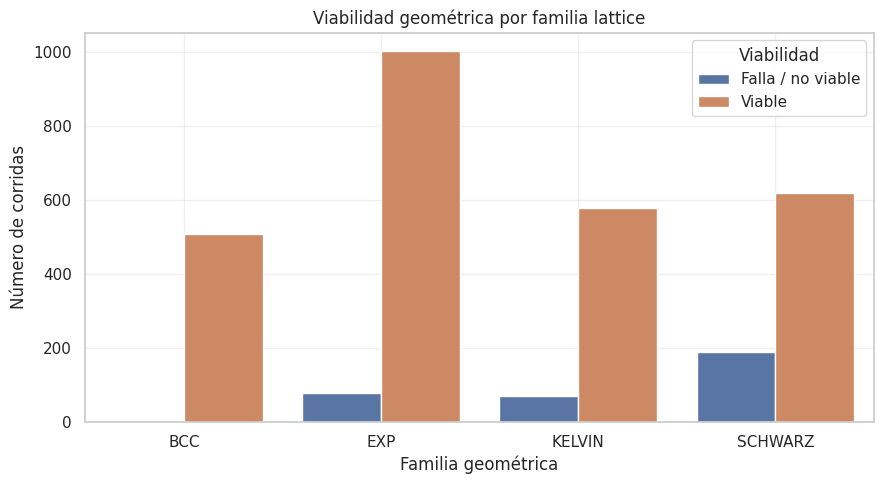

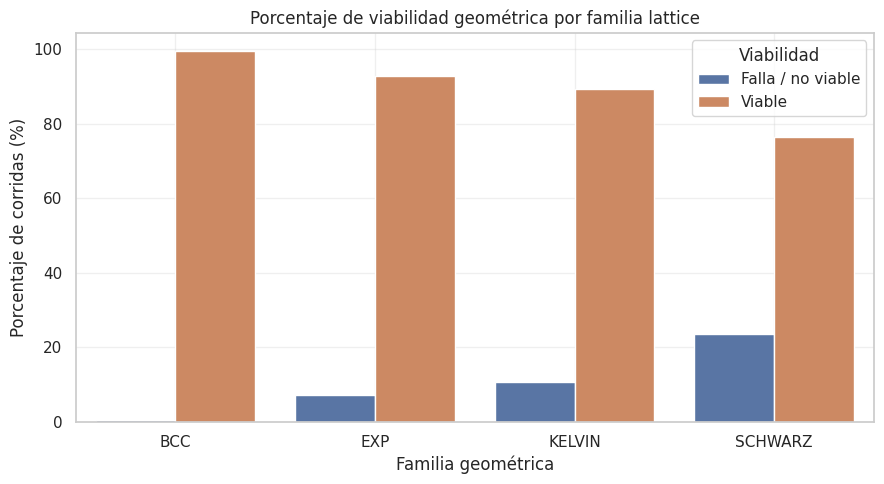

,geometry,rebuild_ok_bin,percentage,status_label
0,BCC,1,99.414062,Viable
1,BCC,0,0.585938,Falla / no viable
2,EXP,1,92.870370,Viable
3,EXP,0,7.129630,Falla / no viable
4,KELVIN,1,89.351852,Viable
5,KELVIN,0,10.648148,Falla / no viable
6,SCHWARZ,1,76.543210,Viable
7,SCHWARZ,0,23.456790,Falla / no viable


In [13]:
# ============================================================
# 2A.2 Viabilidad geométrica: conteos y porcentajes
# ============================================================

plt.figure(figsize=(9, 5))
if sns is not None:
    sns.countplot(data=df_all_processed, x="geometry", hue=BINARY_OUTPUT, order=["BCC", "EXP", "KELVIN", "SCHWARZ"], hue_order=[0, 1])
else:
    df_all_processed.groupby(["geometry", BINARY_OUTPUT]).size().unstack().loc[["BCC", "EXP", "KELVIN", "SCHWARZ"]].plot(kind="bar")
plt.title("Viabilidad geométrica por familia lattice")
plt.xlabel("Familia geométrica")
plt.ylabel("Número de corridas")
plt.legend(title="Viabilidad", labels=["Falla / no viable", "Viable"])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("outputs/figures/2A_viabilidad_conteos_por_familia.png", dpi=300)
plt.show()

viability_pct_plot = (
    df_all_processed.groupby("geometry")[BINARY_OUTPUT]
    .value_counts(normalize=True).mul(100).rename("percentage").reset_index()
)
viability_pct_plot["status_label"] = viability_pct_plot[BINARY_OUTPUT].map({0: "Falla / no viable", 1: "Viable"})

plt.figure(figsize=(9, 5))
if sns is not None:
    sns.barplot(data=viability_pct_plot, x="geometry", y="percentage", hue="status_label", order=["BCC", "EXP", "KELVIN", "SCHWARZ"], hue_order=["Falla / no viable", "Viable"])
else:
    viability_pct_plot.pivot(index="geometry", columns="status_label", values="percentage").loc[["BCC", "EXP", "KELVIN", "SCHWARZ"]].plot(kind="bar")
plt.title("Porcentaje de viabilidad geométrica por familia lattice")
plt.xlabel("Familia geométrica")
plt.ylabel("Porcentaje de corridas (%)")
plt.legend(title="Viabilidad")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("outputs/figures/2A_viabilidad_porcentaje_por_familia.png", dpi=300)
plt.show()

display(viability_pct_plot)

### Interpretación de viabilidad

BCC es la familia más estable, con muy pocas fallas. EXP y Kelvin presentan niveles intermedios, mientras que Schwarz concentra la mayor proporción de reconstrucciones no viables. Por tanto, la clasificación de viabilidad será más informativa en Schwarz, Kelvin y EXP. BCC deberá tratarse con cautela por tener muy pocos ejemplos fallidos.

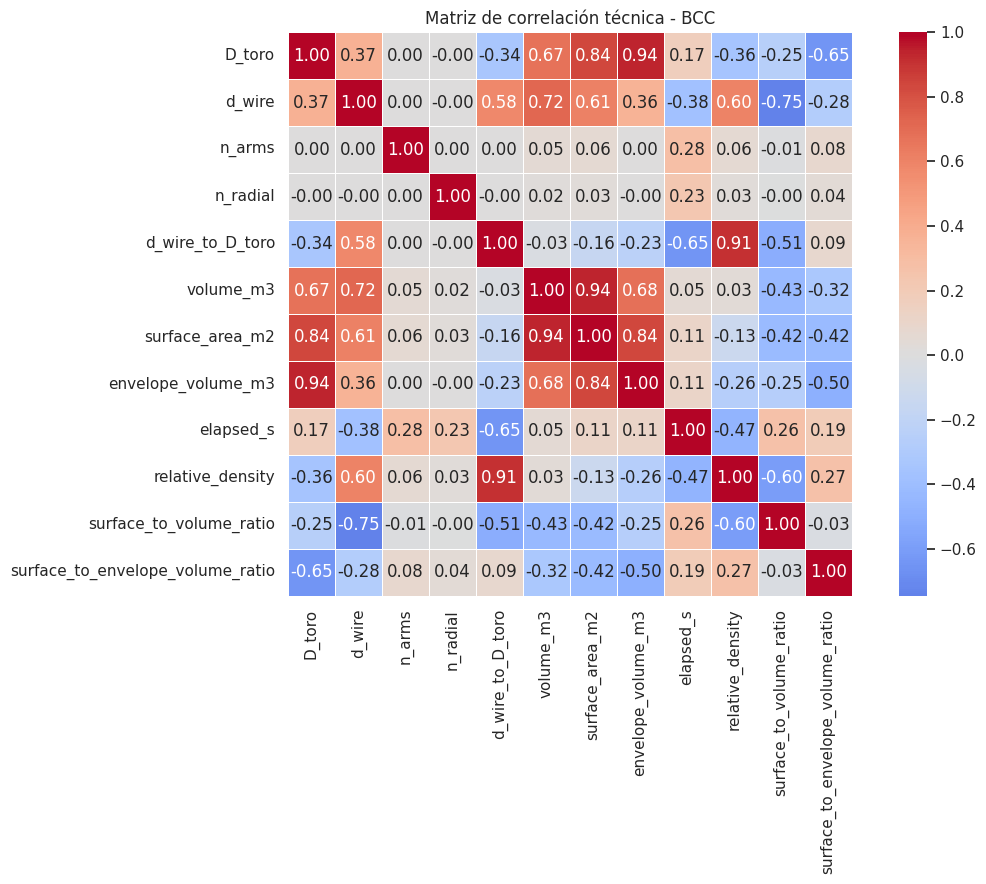

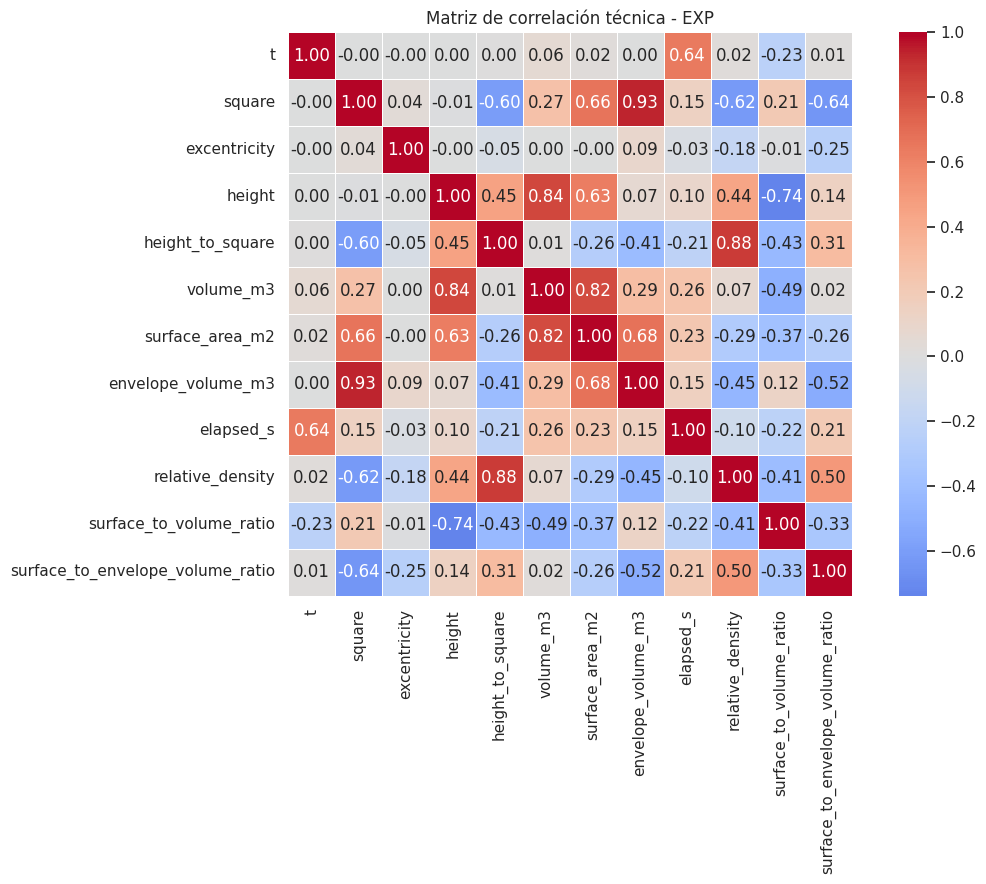

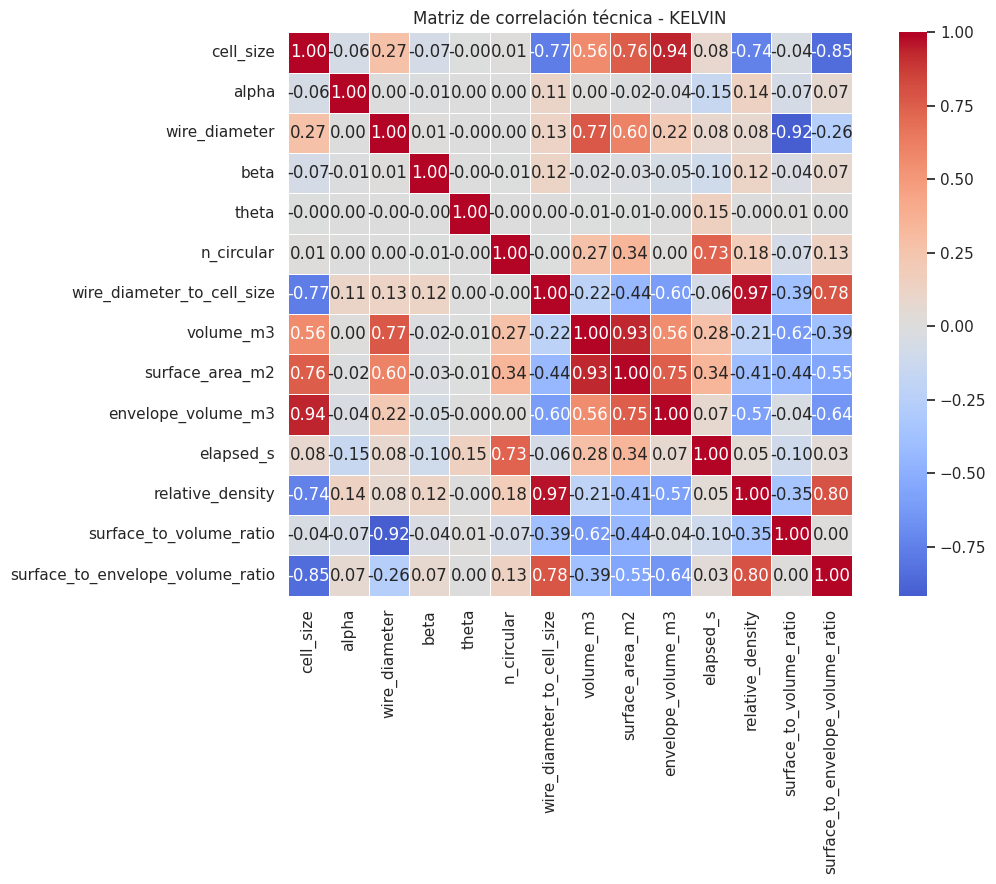

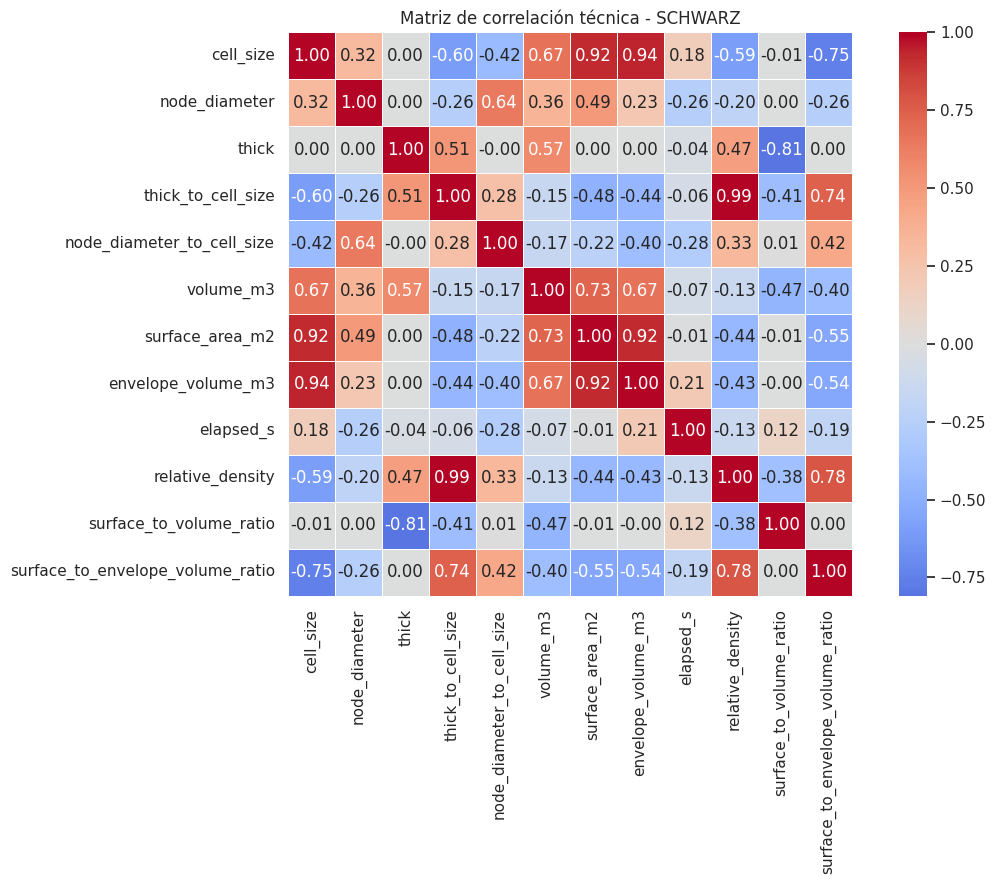

,geometry,input_variable,output_variable,correlation,abs_correlation
0,BCC,D_toro,envelope_volume_m3,0.940533,0.940533
1,BCC,d_wire_to_D_toro,relative_density,0.909139,0.909139
2,BCC,D_toro,surface_area_m2,0.841222,0.841222
3,BCC,d_wire,surface_to_volume_ratio,-0.745388,0.745388
4,BCC,d_wire,volume_m3,0.718641,0.718641
5,BCC,D_toro,volume_m3,0.673787,0.673787
6,BCC,d_wire_to_D_toro,elapsed_s,-0.648665,0.648665
7,BCC,D_toro,surface_to_envelope_volume_ratio,-0.645140,0.645140
8,BCC,d_wire,surface_area_m2,0.611816,0.611816
9,BCC,d_wire,relative_density,0.602260,0.602260


In [14]:
# ============================================================
# 2A.3 Correlaciones intrafamilia y top correlaciones
# ============================================================

EDA_OUTPUT_COLS_MODELING = [
    "volume_m3", "surface_area_m2", "envelope_volume_m3", "elapsed_s",
    "relative_density", "surface_to_volume_ratio", "surface_to_envelope_volume_ratio"
]


def plot_family_correlation_heatmap(df_family, geometry):
    cols = INPUT_COLS_BY_GEOMETRY_BASE[geometry] + CAD_DERIVED_INPUTS_BY_GEOMETRY.get(geometry, [])
    cols += [c for c in EDA_OUTPUT_COLS_MODELING if c in df_family.columns]
    cols = [c for c in cols if c in df_family.columns]
    df_corr = df_family[df_family[BINARY_OUTPUT] == 1][cols].apply(pd.to_numeric, errors="coerce")
    corr = df_corr.corr()

    plt.figure(figsize=(12, 9))
    if sns is not None:
        sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, linewidths=0.5)
    else:
        plt.imshow(corr, cmap="coolwarm", aspect="auto")
        plt.colorbar()
        plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
        plt.yticks(range(len(corr.index)), corr.index)
    plt.title(f"Matriz de correlación técnica - {geometry}")
    plt.tight_layout()
    plt.savefig(f"outputs/figures/2A_corr_heatmap_{geometry}.png", dpi=300)
    plt.show()
    return corr


correlation_matrices = {}
for geometry, df_family in family_dfs.items():
    correlation_matrices[geometry] = plot_family_correlation_heatmap(df_family, geometry)

rows = []
for geometry, corr in correlation_matrices.items():
    input_cols = INPUT_COLS_BY_GEOMETRY_BASE[geometry] + CAD_DERIVED_INPUTS_BY_GEOMETRY.get(geometry, [])
    for input_col in input_cols:
        for output_col in EDA_OUTPUT_COLS_MODELING:
            if input_col in corr.index and output_col in corr.columns:
                value = corr.loc[input_col, output_col]
                rows.append({"geometry": geometry, "input_variable": input_col, "output_variable": output_col, "correlation": value, "abs_correlation": abs(value)})

top_correlations_df = pd.DataFrame(rows).sort_values(["geometry", "abs_correlation"], ascending=[True, False])
display(top_correlations_df.groupby("geometry").head(10).reset_index(drop=True))
top_correlations_df.to_excel("outputs/tables/2A_top_input_output_correlations.xlsx", index=False)

### Interpretación de correlaciones

Los heatmaps permiten ver qué parámetros CAD se asocian más con las salidas físicas. En esta iteración se excluye `porosity` del heatmap principal porque es redundante con `relative_density`. Las variables derivadas se usan para EDA y selección, pero no deben usarse como features si contienen información de la variable objetivo.

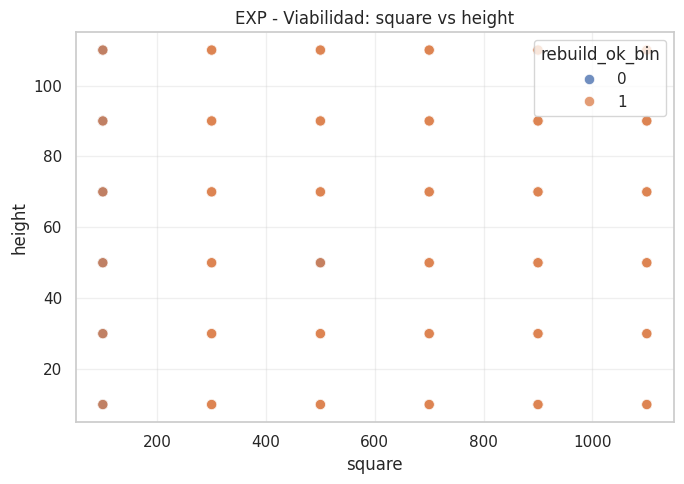

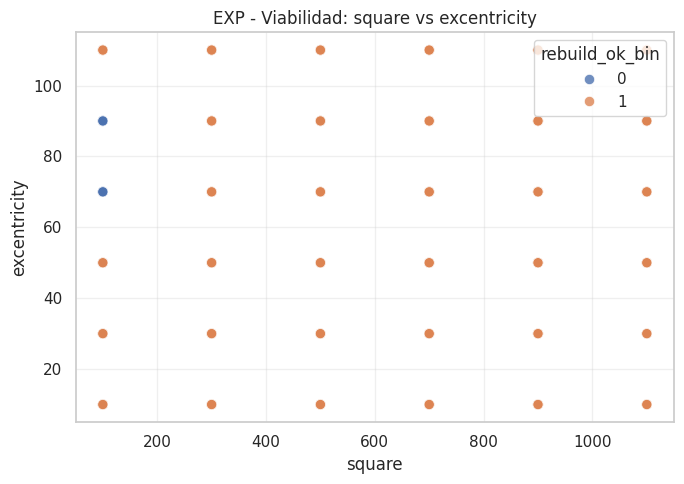

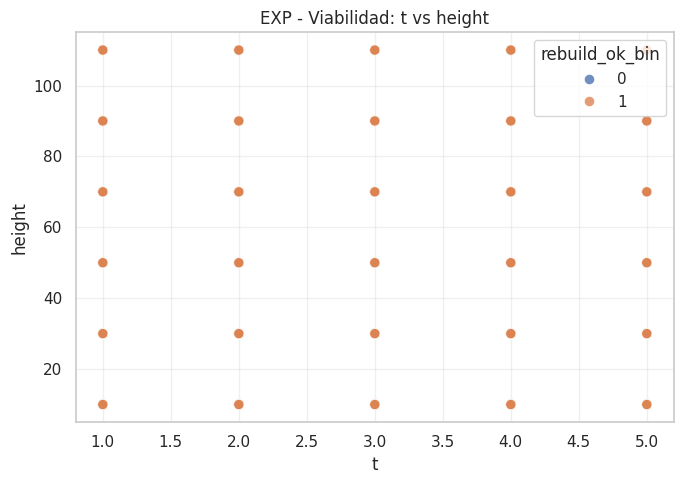

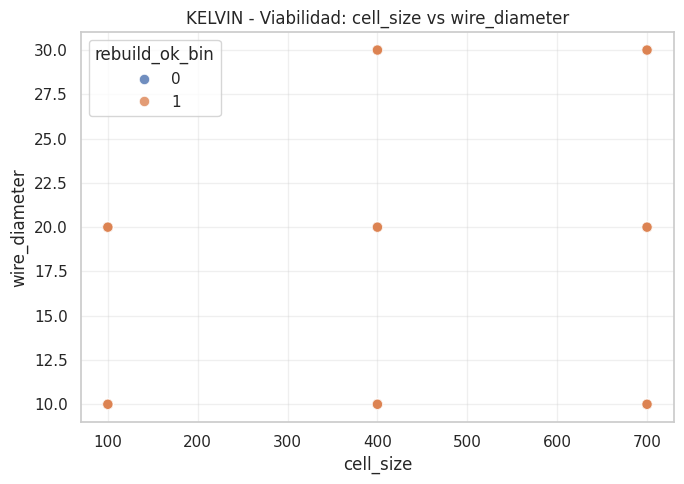

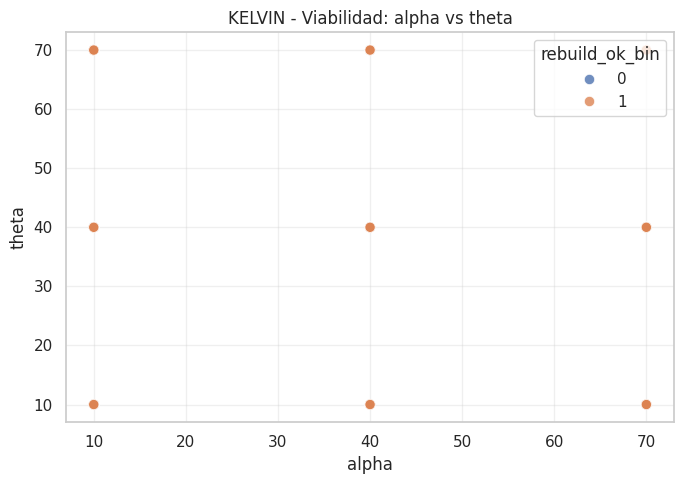

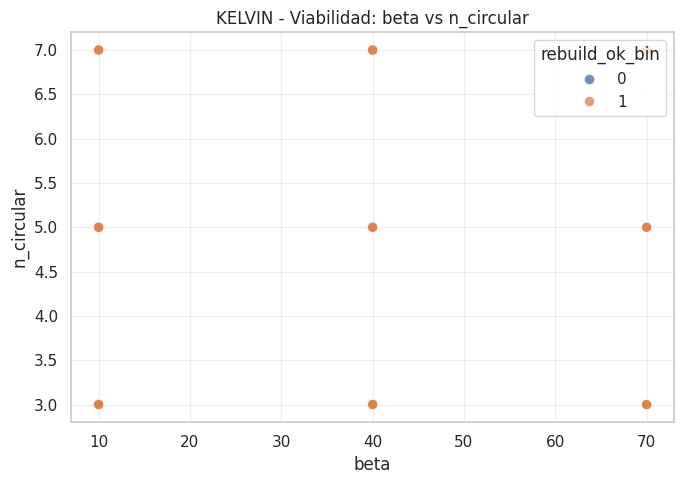

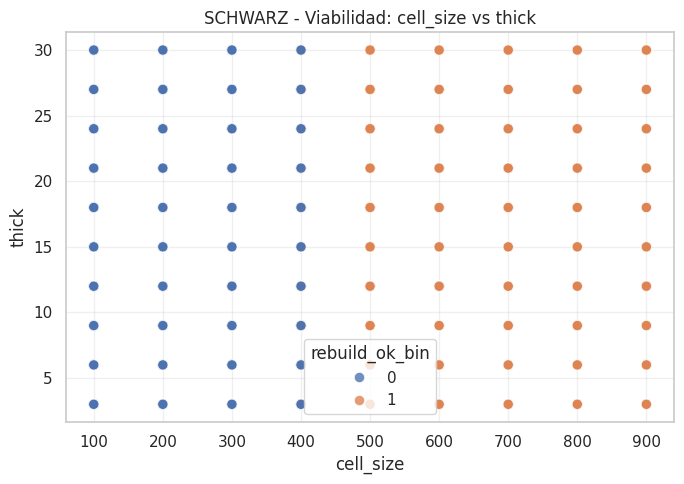

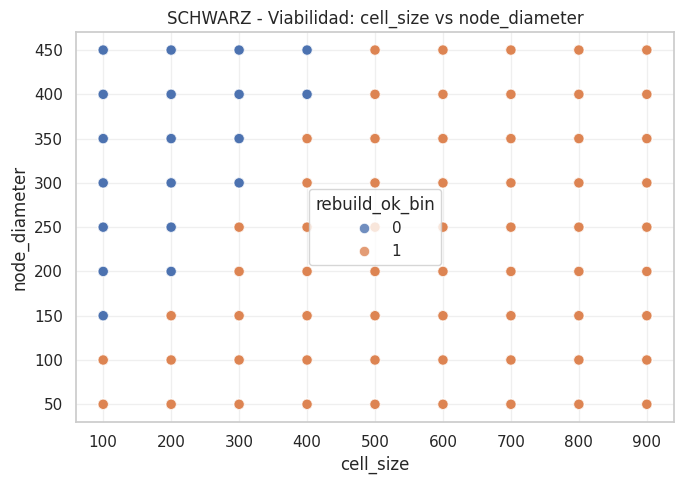

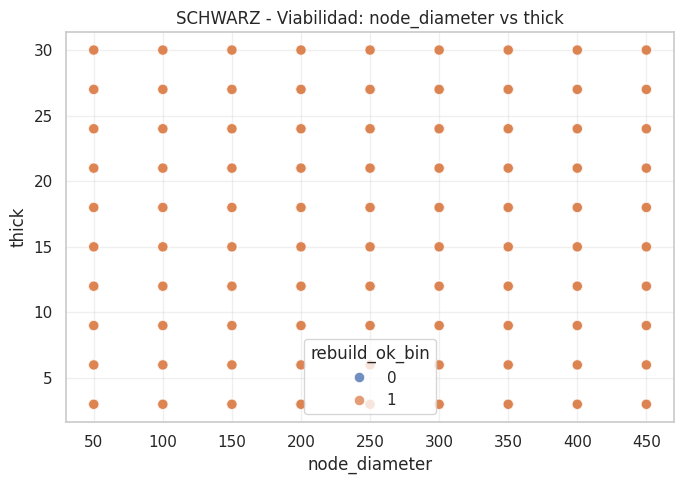

In [15]:
# ============================================================
# 2A.4 Espacio CAD y viabilidad: gráficos focalizados
# ============================================================

VIABILITY_SCATTER_CONFIG = {
    "EXP": [("square", "height"), ("square", "excentricity"), ("t", "height")],
    "KELVIN": [("cell_size", "wire_diameter"), ("alpha", "theta"), ("beta", "n_circular")],
    "SCHWARZ": [("cell_size", "thick"), ("cell_size", "node_diameter"), ("node_diameter", "thick")]
}


def plot_viability_scatter_pairs(df_family, geometry, pairs):
    for x_col, y_col in pairs:
        if x_col not in df_family.columns or y_col not in df_family.columns:
            continue
        df_plot = df_family.dropna(subset=[x_col, y_col, BINARY_OUTPUT]).copy()
        plt.figure(figsize=(7, 5))
        if sns is not None:
            sns.scatterplot(data=df_plot, x=x_col, y=y_col, hue=BINARY_OUTPUT, hue_order=[0, 1], alpha=0.8, s=55)
        else:
            for cls in [0, 1]:
                subset = df_plot[df_plot[BINARY_OUTPUT] == cls]
                plt.scatter(subset[x_col], subset[y_col], alpha=0.8, label=str(cls))
            plt.legend(title=BINARY_OUTPUT)
        plt.title(f"{geometry} - Viabilidad: {x_col} vs {y_col}")
        plt.xlabel(x_col)
        plt.ylabel(y_col)
        plt.grid(True, alpha=0.3)
        plt.legend(title="rebuild_ok_bin")
        plt.tight_layout()
        plt.savefig(f"outputs/figures/2A_viability_scatter_{geometry}_{x_col}_{y_col}.png", dpi=300)
        plt.show()

for geometry, pairs in VIABILITY_SCATTER_CONFIG.items():
    plot_viability_scatter_pairs(family_dfs[geometry], geometry, pairs)

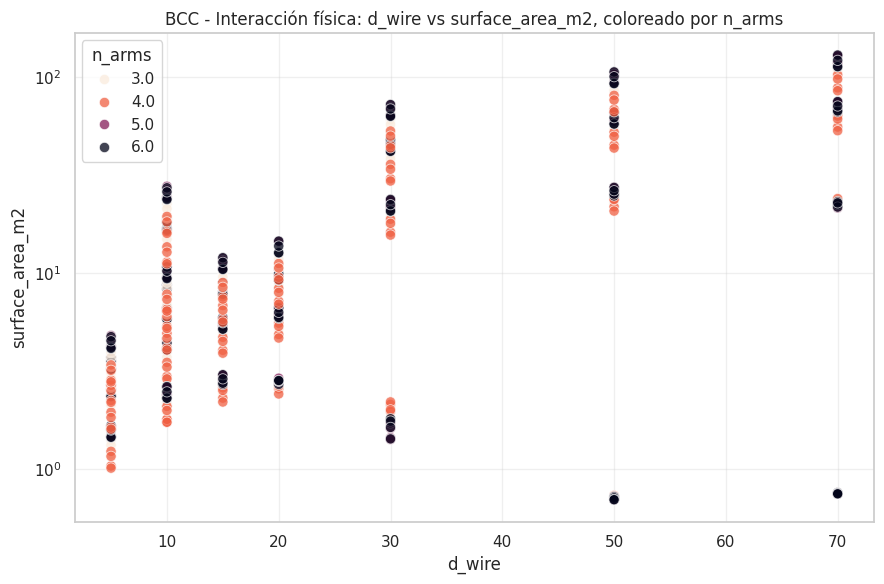

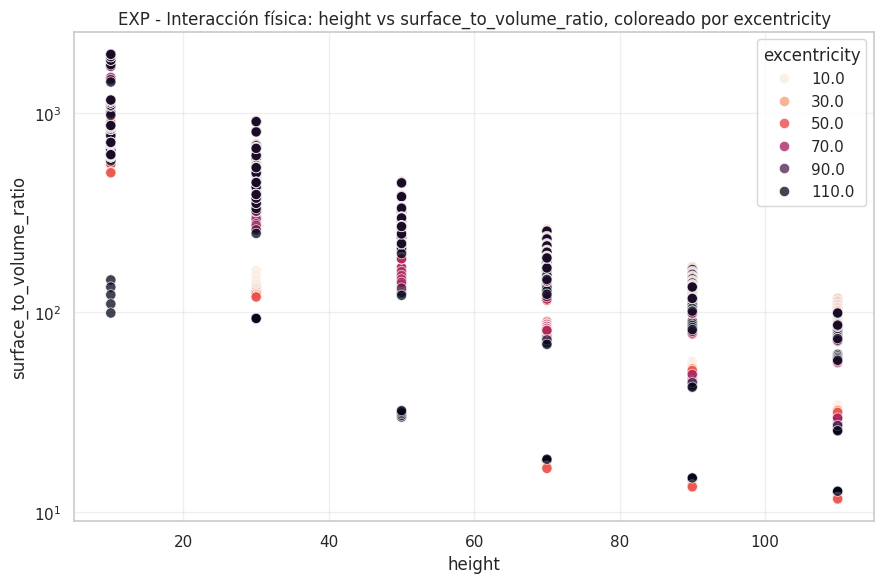

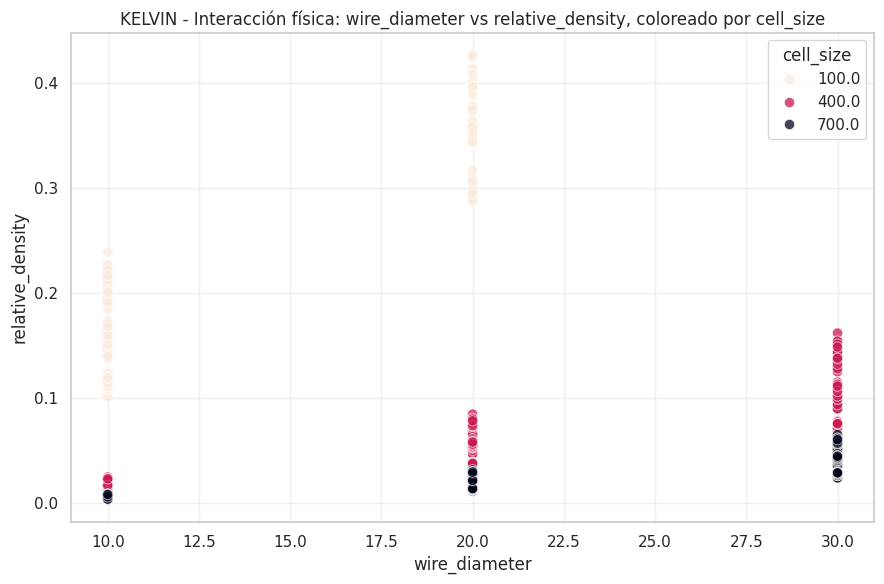

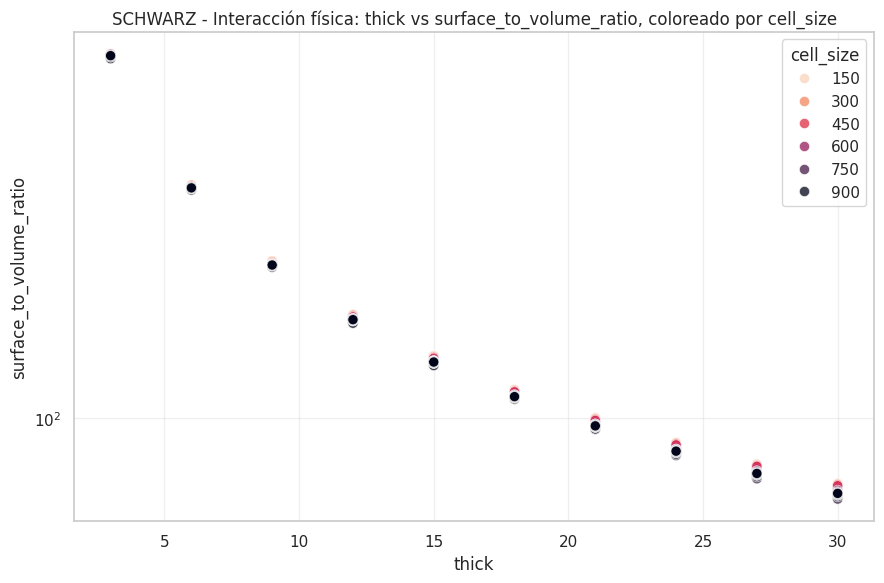

In [16]:
# ============================================================
# 2A.5 Interacciones físicas CAD-salida en geometrías viables
# ============================================================

INTERACTION_CONFIG = {
    "BCC": {"x": "d_wire", "y": "surface_area_m2", "color": "n_arms"},
    "EXP": {"x": "height", "y": "surface_to_volume_ratio", "color": "excentricity"},
    "KELVIN": {"x": "wire_diameter", "y": "relative_density", "color": "cell_size"},
    "SCHWARZ": {"x": "thick", "y": "surface_to_volume_ratio", "color": "cell_size"}
}


def plot_interaction_scatter(df_family, geometry, config):
    x, y, color = config["x"], config["y"], config["color"]
    if not set([x, y, color]).issubset(df_family.columns):
        return
    df_plot = df_family[df_family[BINARY_OUTPUT] == 1].dropna(subset=[x, y, color]).copy()
    plt.figure(figsize=(9, 6))
    if sns is not None:
        sns.scatterplot(data=df_plot, x=x, y=y, hue=color, palette="rocket_r", alpha=0.75, s=55)
    else:
        plt.scatter(df_plot[x], df_plot[y], c=df_plot[color], alpha=0.75)
        plt.colorbar(label=color)
    plt.title(f"{geometry} - Interacción física: {x} vs {y}, coloreado por {color}")
    plt.xlabel(x)
    plt.ylabel(y)
    plt.grid(True, alpha=0.3)
    if y in ["surface_to_volume_ratio", "surface_area_m2"] and (df_plot[y].dropna() > 0).all():
        plt.yscale("log")
    plt.tight_layout()
    plt.savefig(f"outputs/figures/2A_interaction_{geometry}_{x}_{y}_{color}.png", dpi=300)
    plt.show()

for geometry, config in INTERACTION_CONFIG.items():
    plot_interaction_scatter(family_dfs[geometry], geometry, config)

### Lectura de interacciones

Las interacciones físicas muestran que las propiedades dependen de proporciones geométricas, no solo de dimensiones absolutas. Esto justifica los ratios CAD adimensionales creados en la Sección 1, como `wire_diameter_to_cell_size` y `thick_to_cell_size`.

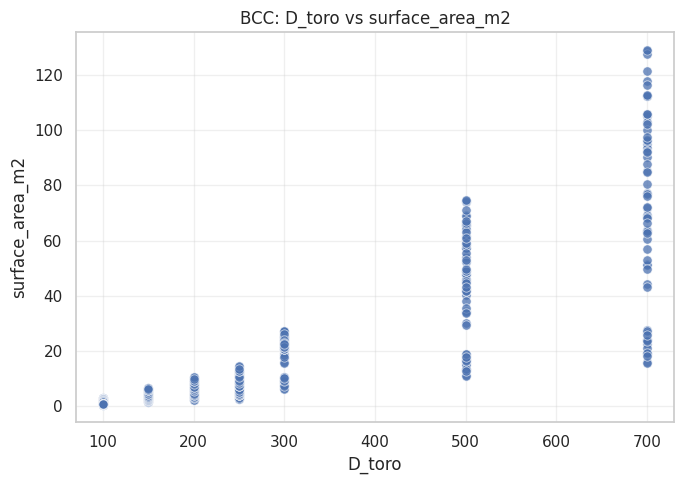

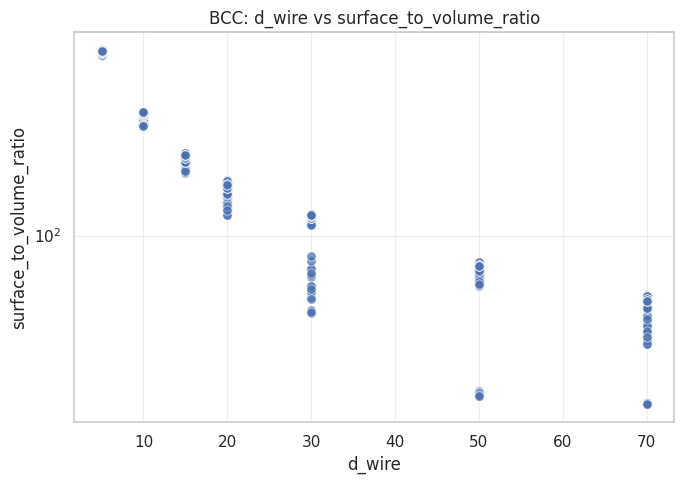

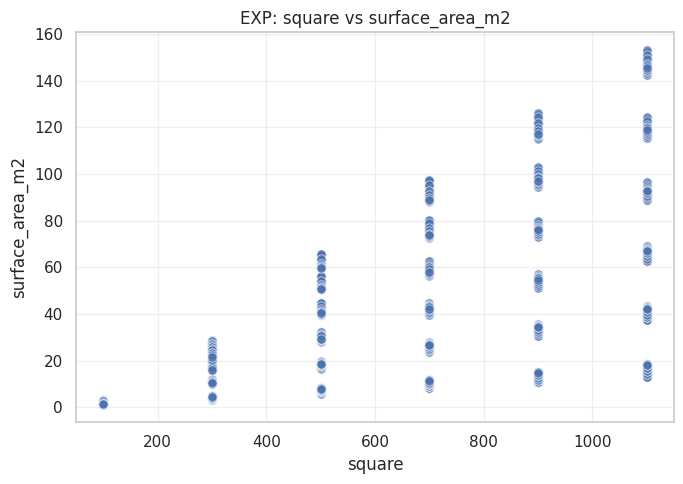

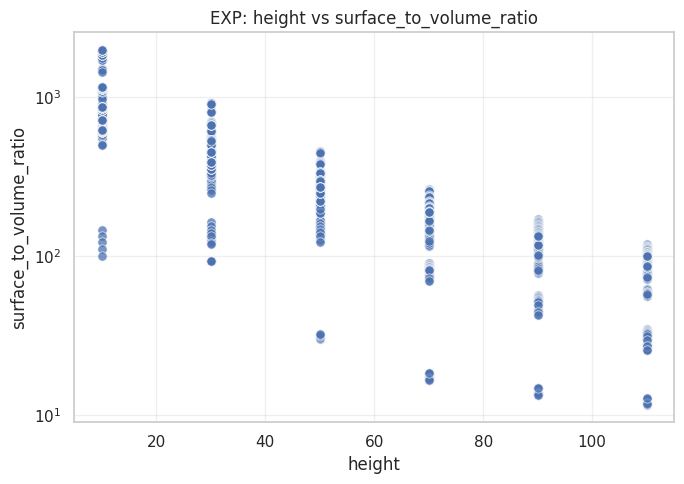

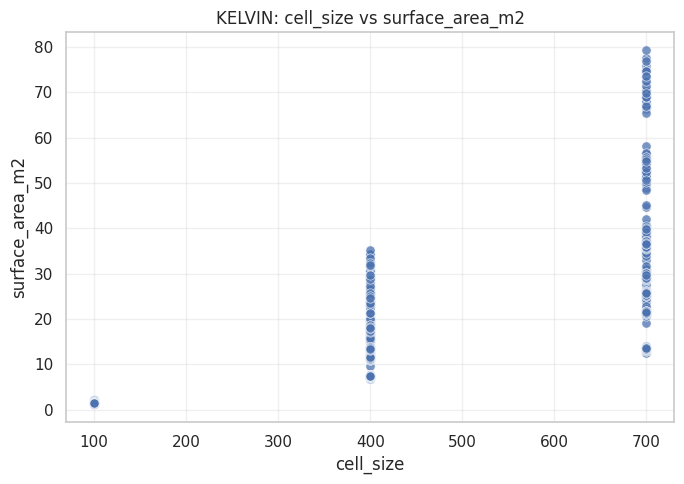

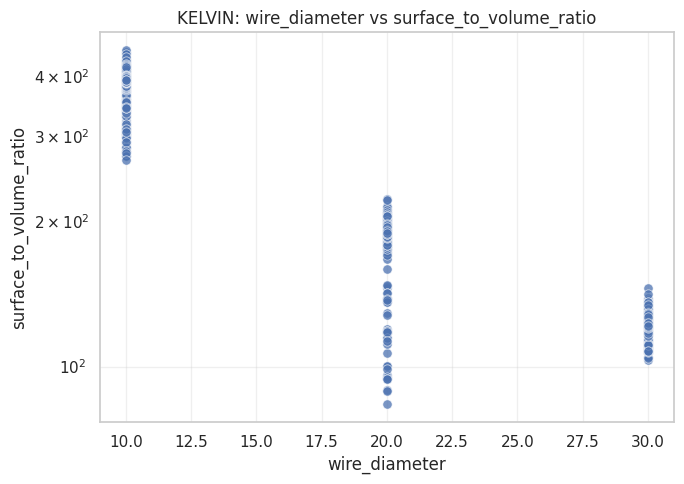

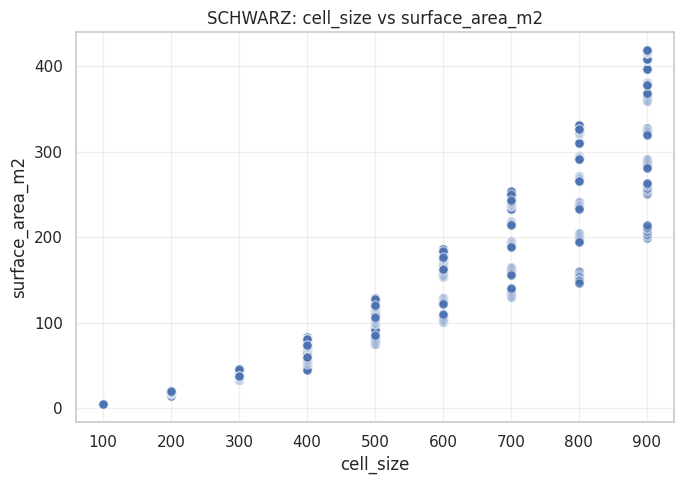

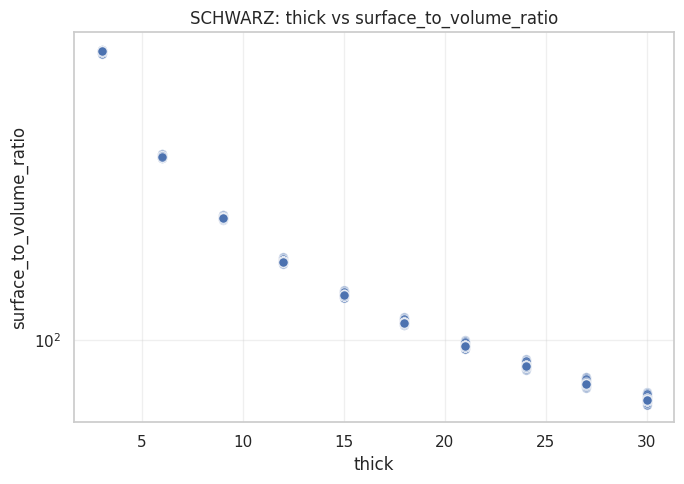

In [17]:
# ============================================================
# 2A.6 Gráficos focalizados CAD-física
# ============================================================

CAD_PHYSICS_SCATTER_CONFIG = {
    "BCC": [("D_toro", "surface_area_m2"), ("d_wire", "surface_to_volume_ratio")],
    "EXP": [("square", "surface_area_m2"), ("height", "surface_to_volume_ratio")],
    "KELVIN": [("cell_size", "surface_area_m2"), ("wire_diameter", "surface_to_volume_ratio")],
    "SCHWARZ": [("cell_size", "surface_area_m2"), ("thick", "surface_to_volume_ratio")]
}

for geometry, pairs in CAD_PHYSICS_SCATTER_CONFIG.items():
    df_family_viable = family_dfs[geometry][family_dfs[geometry][BINARY_OUTPUT] == 1].copy()
    for x_col, y_col in pairs:
        if x_col not in df_family_viable.columns or y_col not in df_family_viable.columns:
            continue
        df_plot = df_family_viable.dropna(subset=[x_col, y_col]).copy()
        plt.figure(figsize=(7, 5))
        if sns is not None:
            sns.scatterplot(data=df_plot, x=x_col, y=y_col, alpha=0.75, s=45)
        else:
            plt.scatter(df_plot[x_col], df_plot[y_col], alpha=0.75)
        plt.title(f"{geometry}: {x_col} vs {y_col}")
        plt.xlabel(x_col)
        plt.ylabel(y_col)
        plt.grid(True, alpha=0.3)
        if y_col == "surface_to_volume_ratio" and (df_plot[y_col].dropna() > 0).all():
            plt.yscale("log")
        plt.tight_layout()
        plt.savefig(f"outputs/figures/2A_cad_physics_scatter_{geometry}_{x_col}_{y_col}.png", dpi=300)
        plt.show()

In [18]:
# ============================================================
# 2A.7 Pairplots opcionales de diagnóstico
# ============================================================

if RUN_PAIRPLOTS:
    # Pairplots físicos solo para EXP y SCHWARZ para no saturar el notebook
    pairplot_config = {
        "EXP": ["square", "height", "surface_area_m2", "relative_density", "surface_to_volume_ratio"],
        "SCHWARZ": ["cell_size", "thick", "surface_area_m2", "relative_density", "surface_to_volume_ratio"]
    }
    for geometry, cols in pairplot_config.items():
        cols = [c for c in cols if c in family_dfs[geometry].columns]
        df_plot = family_dfs[geometry][family_dfs[geometry][BINARY_OUTPUT] == 1][cols].dropna().copy()
        if len(df_plot) > 700:
            df_plot = df_plot.sample(700, random_state=RANDOM_STATE)
        if sns is not None and len(df_plot) > 5:
            g = sns.pairplot(df_plot, vars=cols, corner=True, diag_kind="hist", plot_kws={"alpha": 0.65, "s": 25})
            g.fig.suptitle(f"Relaciones CAD-física en geometrías viables - {geometry}", y=1.02)
            g.fig.savefig(f"outputs/figures/2A_pairplot_physical_{geometry}.png", dpi=300, bbox_inches="tight")
            plt.show()
else:
    print("RUN_PAIRPLOTS=False. Pairplots omitidos por defecto para optimizar ejecución.")

RUN_PAIRPLOTS=False. Pairplots omitidos por defecto para optimizar ejecución.


relative_density                                               \
                    count     mean   median      min      max      std   
geometry                                                                 
BCC                   509 0.256153 0.161612 0.004306 0.961586 0.275650   
EXP                  1003 0.089479 0.026320 0.000149 0.750945 0.149190   
KELVIN                579 0.075553 0.039541 0.002984 0.426497 0.089493   
SCHWARZ               620 0.036921 0.026821 0.001924 0.323783 0.040529   

         porosity                                               \
            count     mean   median      min      max      std   
geometry                                                         
BCC           509 0.743847 0.838388 0.038414 0.995694 0.275650   
EXP          1003 0.910521 0.973680 0.249055 0.999851 0.149190   
KELVIN        579 0.924447 0.960459 0.573503 0.997016 0.089493   
SCHWARZ       620 0.963079 0.973179 0.676217 0.998076 0.040529   

         surface_to_volume_ratio                                               \
                           count       mean     median       min          max   
geometry                                                                        
BCC                          509 263.702089 202.738418 15.420761   781.924022   
EXP                         1003 322.952218 168.001790 11.594234 1,970.752749   
KELVIN                       579 240.961277 194.349852 83.508113   452.683243   
SCHWARZ                      620 196.349051 123.837947 65.375666   674.007561   

                    surface_to_envelope_volume_ratio                      \
                std                            count      mean    median   
geometry                                                                   
BCC      226.853279                              509 30.080581 23.244112   
EXP      370.332755                             1003  6.173274  3.967911   
KELVIN   115.646628                              579 14.549974  7.124872   
SCHWARZ  175.452520                              620  4.550640  3.372932   

                                       
              min       max       std  
geometry                               
BCC      1.692291 96.770013 23.703556  
EXP      0.293152 55.108779  6.631587  
KELVIN   1.314853 68.596999 16.878109  
SCHWARZ  1.266121 23.856750  4.039329

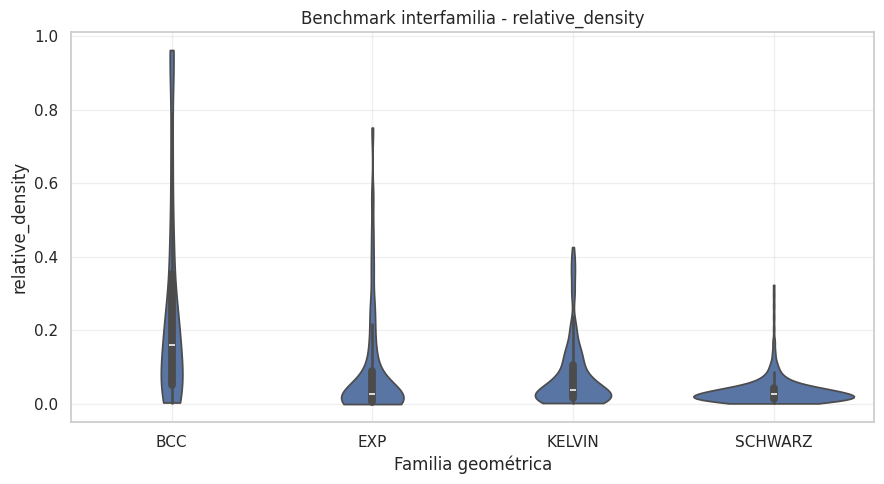

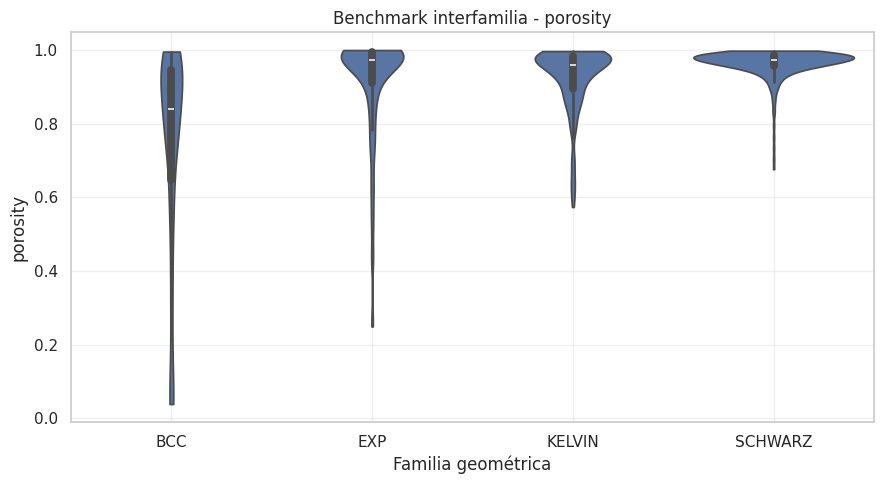

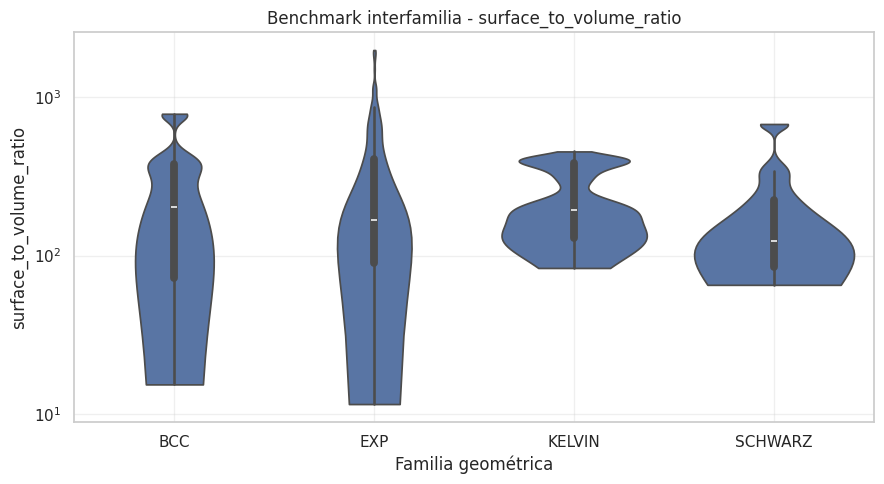

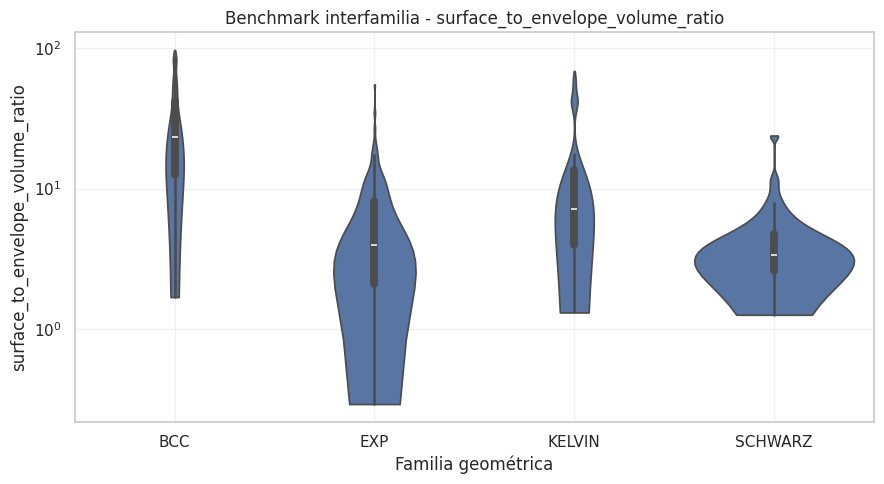

In [19]:
# ============================================================
# 2A.8 Benchmarking interfamilia
# ============================================================

BENCHMARK_METRICS = ["relative_density", "porosity", "surface_to_volume_ratio", "surface_to_envelope_volume_ratio"]
available_benchmark_metrics = [c for c in BENCHMARK_METRICS if c in df_viable.columns]

benchmark_summary = df_viable.groupby("geometry")[available_benchmark_metrics].agg(["count", "mean", "median", "min", "max", "std"])
display(benchmark_summary)
benchmark_summary.to_excel("outputs/tables/2A_benchmark_summary_by_geometry.xlsx")

for metric in available_benchmark_metrics:
    plt.figure(figsize=(9, 5))
    if sns is not None:
        sns.violinplot(data=df_viable, x="geometry", y=metric, inner="box", cut=0, order=["BCC", "EXP", "KELVIN", "SCHWARZ"])
    else:
        df_viable.boxplot(column=metric, by="geometry", figsize=(9, 5))
        plt.suptitle("")
    plt.title(f"Benchmark interfamilia - {metric}")
    plt.xlabel("Familia geométrica")
    plt.ylabel(metric)
    plt.grid(True, alpha=0.3)
    if metric in ["surface_to_volume_ratio", "surface_to_envelope_volume_ratio"] and (df_viable[metric].dropna() > 0).all():
        plt.yscale("log")
    plt.tight_layout()
    plt.savefig(f"outputs/figures/2A_benchmark_{metric}.png", dpi=300)
    plt.show()

### Benchmarking interfamilia

Las métricas derivadas permiten comparar familias desde una perspectiva de ingeniería: densidad relativa, porosidad, área por volumen sólido y área por volumen envolvente. Estas métricas enriquecen la narrativa de diseño, pero deben manejarse cuidadosamente para evitar fuga de información en modelado.

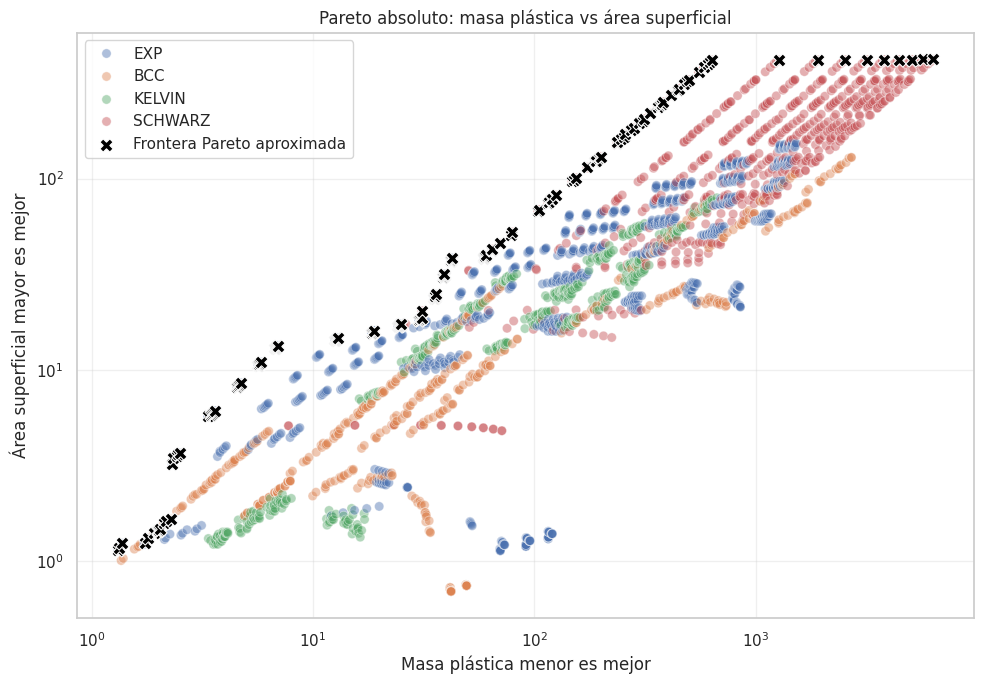

Candidatos Pareto absolutos por geometría:


,geometry,pareto_candidates,pareto_share_pct
1,EXP,81,54.000000
2,SCHWARZ,60,40.000000
0,BCC,9,6.000000


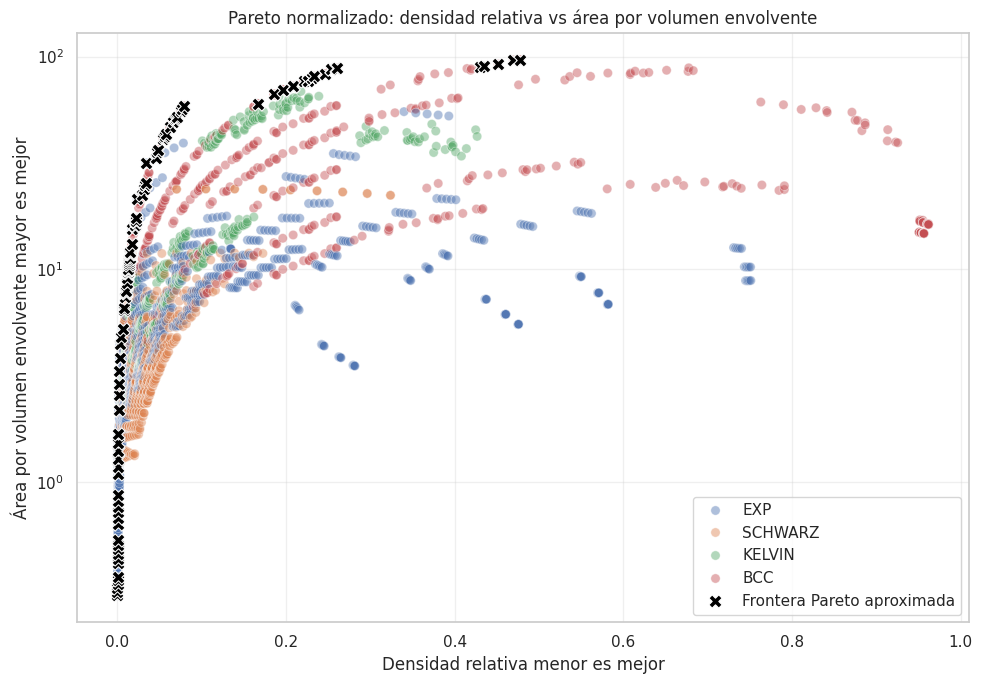

Candidatos Pareto normalizados por geometría:


,geometry,pareto_candidates,pareto_share_pct
0,BCC,71,66.355140
1,EXP,36,33.644860


In [20]:
# ============================================================
# 2A.9 Pareto absoluto y normalizado
# ============================================================

def pareto_front_min_x_max_y(df, x_col, y_col, eps=1e-12):
    df_p = df.dropna(subset=[x_col, y_col]).copy()
    df_p = df_p[np.isfinite(df_p[x_col]) & np.isfinite(df_p[y_col]) & (df_p[x_col] > 0) & (df_p[y_col] > 0)].copy()
    df_p = df_p.sort_values([x_col, y_col], ascending=[True, False]).reset_index(drop=True)
    best_y = -np.inf
    pareto_indices = []
    for idx, row in df_p.iterrows():
        if row[y_col] > best_y + eps:
            pareto_indices.append(idx)
            best_y = row[y_col]
    df_p["is_pareto"] = False
    df_p.loc[pareto_indices, "is_pareto"] = True
    return df_p


def pareto_geometry_summary(pareto_df):
    summary = pareto_df[pareto_df["is_pareto"]].groupby("geometry").size().reset_index(name="pareto_candidates").sort_values("pareto_candidates", ascending=False)
    total = summary["pareto_candidates"].sum()
    summary["pareto_share_pct"] = 100 * summary["pareto_candidates"] / total if total > 0 else np.nan
    return summary


pareto_abs_df = pareto_front_min_x_max_y(df_viable, "plastic_mass_kg", "surface_area_m2")
pareto_norm_df = pareto_front_min_x_max_y(df_viable, "relative_density", "surface_to_envelope_volume_ratio")

# Pareto absoluto
plt.figure(figsize=(10, 7))
if sns is not None:
    sns.scatterplot(data=pareto_abs_df, x="plastic_mass_kg", y="surface_area_m2", hue="geometry", alpha=0.45, s=45)
    sns.scatterplot(data=pareto_abs_df[pareto_abs_df["is_pareto"]], x="plastic_mass_kg", y="surface_area_m2", color="black", s=90, marker="X", label="Frontera Pareto aproximada")
else:
    plt.scatter(pareto_abs_df["plastic_mass_kg"], pareto_abs_df["surface_area_m2"], alpha=0.45)
plt.title("Pareto absoluto: masa plástica vs área superficial")
plt.xlabel("Masa plástica menor es mejor")
plt.ylabel("Área superficial mayor es mejor")
plt.xscale("log")
plt.yscale("log")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("outputs/figures/2A_pareto_absoluto_masa_plastica_area.png", dpi=300)
plt.show()

pareto_abs_geometry_summary = pareto_geometry_summary(pareto_abs_df)
print("Candidatos Pareto absolutos por geometría:")
display(pareto_abs_geometry_summary)

# Pareto normalizado
plt.figure(figsize=(10, 7))
if sns is not None:
    sns.scatterplot(data=pareto_norm_df, x="relative_density", y="surface_to_envelope_volume_ratio", hue="geometry", alpha=0.45, s=45)
    sns.scatterplot(data=pareto_norm_df[pareto_norm_df["is_pareto"]], x="relative_density", y="surface_to_envelope_volume_ratio", color="black", s=90, marker="X", label="Frontera Pareto aproximada")
else:
    plt.scatter(pareto_norm_df["relative_density"], pareto_norm_df["surface_to_envelope_volume_ratio"], alpha=0.45)
plt.title("Pareto normalizado: densidad relativa vs área por volumen envolvente")
plt.xlabel("Densidad relativa menor es mejor")
plt.ylabel("Área por volumen envolvente mayor es mejor")
plt.yscale("log")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("outputs/figures/2A_pareto_normalizado_densidad_area_envolvente.png", dpi=300)
plt.show()

pareto_norm_geometry_summary = pareto_geometry_summary(pareto_norm_df)
print("Candidatos Pareto normalizados por geometría:")
display(pareto_norm_geometry_summary)

### Interpretación de Pareto

El Pareto absoluto responde qué diseño entrega mayor área superficial con menor masa plástica. El Pareto normalizado responde qué diseño entrega mayor área por volumen envolvente con menor densidad relativa. Este segundo criterio es más justo para comparar familias, porque reduce el sesgo hacia geometrías grandes.

In [21]:
# ============================================================
# 2A.10 Diseños destacados con tabla compacta
# ============================================================

def make_cad_params_string(row):
    geometry = row["geometry"]
    cols = INPUT_COLS_BY_GEOMETRY_BASE[geometry] + CAD_DERIVED_INPUTS_BY_GEOMETRY.get(geometry, [])
    parts = []
    for col in cols:
        if col in row.index and pd.notna(row[col]):
            val = row[col]
            parts.append(f"{col}={val:.4g}" if isinstance(val, (float, np.floating)) else f"{col}={val}")
    return "; ".join(parts)


def compact_design_table(df, n=10):
    cols = [
        "geometry", "cad_params", "surface_area_m2", "volume_m3", "envelope_volume_m3",
        "relative_density", "porosity", "surface_to_volume_ratio",
        "surface_to_envelope_volume_ratio", "plastic_mass_kg", "steel_mass_kg", "elapsed_s"
    ]
    out = df.copy()
    out["cad_params"] = out.apply(make_cad_params_string, axis=1)
    return out[[c for c in cols if c in out.columns]].head(n)


top_surface_to_volume = df_viable.dropna(subset=["surface_to_volume_ratio"]).sort_values("surface_to_volume_ratio", ascending=False)
top_porosity = df_viable.dropna(subset=["porosity"]).sort_values("porosity", ascending=False)
top_surface_to_envelope = df_viable.dropna(subset=["surface_to_envelope_volume_ratio"]).sort_values("surface_to_envelope_volume_ratio", ascending=False)
top_pareto_abs = pareto_abs_df[pareto_abs_df["is_pareto"]].sort_values(["plastic_mass_kg", "surface_area_m2"], ascending=[True, False])
top_pareto_norm = pareto_norm_df[pareto_norm_df["is_pareto"]].sort_values(["relative_density", "surface_to_envelope_volume_ratio"], ascending=[True, False])

print("Top diseños por ratio área/volumen:")
display(compact_design_table(top_surface_to_volume, 10))
print("Top diseños por porosidad:")
display(compact_design_table(top_porosity, 10))
print("Candidatos Pareto absolutos:")
display(compact_design_table(top_pareto_abs, 10))
print("Candidatos Pareto normalizados:")
display(compact_design_table(top_pareto_norm, 10))

Top diseños por ratio área/volumen:


,geometry,cad_params,surface_area_m2,volume_m3,envelope_volume_m3,relative_density,porosity,surface_to_volume_ratio,surface_to_envelope_volume_ratio,plastic_mass_kg,steel_mass_kg,elapsed_s
692,EXP,t=1; square=1100; excentricity=10; height=10; height_to_square=0.009091,13.410450,0.006805,37.259704,0.000183,0.999817,"1,970.752749",0.359918,6.940830,53.757405,15.037005
698,EXP,t=1; square=1100; excentricity=30; height=10; height_to_square=0.009091,13.328773,0.006769,38.614472,0.000175,0.999825,"1,969.223298",0.345176,6.903914,53.471492,14.641704
704,EXP,t=1; square=1100; excentricity=50; height=10; height_to_square=0.009091,13.242238,0.006730,40.001688,0.000168,0.999832,"1,967.759585",0.331042,6.864194,53.163854,14.888632
710,EXP,t=1; square=1100; excentricity=70; height=10; height_to_square=0.009091,13.161765,0.006693,41.421736,0.000162,0.999838,"1,966.523621",0.317750,6.826768,52.873987,15.210855
716,EXP,t=1; square=1100; excentricity=90; height=10; height_to_square=0.009091,13.083513,0.006657,42.875000,0.000155,0.999845,"1,965.406282",0.305155,6.790038,52.589509,15.345927
722,EXP,t=1; square=1100; excentricity=110; height=10; height_to_square=0.009091,13.004787,0.006621,44.361864,0.000149,0.999851,"1,964.128089",0.293152,6.753573,52.307085,14.317266
656,EXP,t=1; square=900; excentricity=10; height=10; height_to_square=0.01111,10.982274,0.005716,20.570824,0.000278,0.999722,"1,921.435020",0.533876,5.829976,45.153733,14.587790
662,EXP,t=1; square=900; excentricity=30; height=10; height_to_square=0.01111,10.900562,0.005679,21.484952,0.000264,0.999736,"1,919.308722",0.507358,5.793009,44.867426,15.639042
668,EXP,t=1; square=900; excentricity=50; height=10; height_to_square=0.01111,10.817310,0.005642,22.425768,0.000252,0.999748,"1,917.392627",0.482361,5.754510,44.569248,15.062768
674,EXP,t=1; square=900; excentricity=70; height=10; height_to_square=0.01111,10.739148,0.005606,23.393656,0.000240,0.999760,"1,915.796896",0.459062,5.717689,44.284062,14.246431


Top diseños por porosidad:


,geometry,cad_params,surface_area_m2,volume_m3,envelope_volume_m3,relative_density,porosity,surface_to_volume_ratio,surface_to_envelope_volume_ratio,plastic_mass_kg,steel_mass_kg,elapsed_s
722,EXP,t=1; square=1100; excentricity=110; height=10; height_to_square=0.009091,13.004787,0.006621,44.361864,0.000149,0.999851,"1,964.128089",0.293152,6.753573,52.307085,14.317266
716,EXP,t=1; square=1100; excentricity=90; height=10; height_to_square=0.009091,13.083513,0.006657,42.875000,0.000155,0.999845,"1,965.406282",0.305155,6.790038,52.589509,15.345927
710,EXP,t=1; square=1100; excentricity=70; height=10; height_to_square=0.009091,13.161765,0.006693,41.421736,0.000162,0.999838,"1,966.523621",0.317750,6.826768,52.873987,15.210855
704,EXP,t=1; square=1100; excentricity=50; height=10; height_to_square=0.009091,13.242238,0.006730,40.001688,0.000168,0.999832,"1,967.759585",0.331042,6.864194,53.163854,14.888632
698,EXP,t=1; square=1100; excentricity=30; height=10; height_to_square=0.009091,13.328773,0.006769,38.614472,0.000175,0.999825,"1,969.223298",0.345176,6.903914,53.471492,14.641704
692,EXP,t=1; square=1100; excentricity=10; height=10; height_to_square=0.009091,13.410450,0.006805,37.259704,0.000183,0.999817,"1,970.752749",0.359918,6.940830,53.757405,15.037005
686,EXP,t=1; square=900; excentricity=110; height=10; height_to_square=0.01111,10.583578,0.005535,25.412184,0.000218,0.999782,"1,912.077558",0.416477,5.645822,43.727447,14.397784
680,EXP,t=1; square=900; excentricity=90; height=10; height_to_square=0.01111,10.660454,0.005570,24.389000,0.000228,0.999772,"1,913.976424",0.437101,5.681189,44.001370,14.185023
674,EXP,t=1; square=900; excentricity=70; height=10; height_to_square=0.01111,10.739148,0.005606,23.393656,0.000240,0.999760,"1,915.796896",0.459062,5.717689,44.284062,14.246431
668,EXP,t=1; square=900; excentricity=50; height=10; height_to_square=0.01111,10.817310,0.005642,22.425768,0.000252,0.999748,"1,917.392627",0.482361,5.754510,44.569248,15.062768


Candidatos Pareto absolutos:


,geometry,cad_params,surface_area_m2,volume_m3,envelope_volume_m3,relative_density,porosity,surface_to_volume_ratio,surface_to_envelope_volume_ratio,plastic_mass_kg,steel_mass_kg,elapsed_s
0,EXP,t=1; square=100; excentricity=50; height=10; height_to_square=0.1,1.144987,0.001286,0.074088,0.017357,0.982643,890.393112,15.454416,1.311653,10.158879,14.493315
1,EXP,t=1; square=100; excentricity=30; height=10; height_to_square=0.1,1.173573,0.001298,0.054872,0.023647,0.976353,904.457293,21.387459,1.323494,10.250593,14.838273
3,EXP,t=1; square=100; excentricity=10; height=10; height_to_square=0.1,1.244213,0.001345,0.039304,0.034231,0.965769,924.788214,31.656147,1.372311,10.628687,17.653688
10,EXP,t=2; square=100; excentricity=30; height=10; height_to_square=0.1,1.246570,0.001707,0.054872,0.031101,0.968899,730.456066,22.717778,1.740695,13.481854,16.225969
11,BCC,D_toro=100; d_wire=5; n_arms=3; n_radial=6; d_wire_to_D_toro=0.05,1.321948,0.001763,0.028373,0.062126,0.937874,749.960693,46.592358,1.797943,13.925243,11.512582
13,BCC,D_toro=100; d_wire=5; n_arms=3; n_radial=5; d_wire_to_D_toro=0.05,1.400279,0.001867,0.028373,0.065792,0.934208,750.144115,49.353163,1.904013,14.746770,12.855956
14,BCC,D_toro=100; d_wire=5; n_arms=6; n_radial=4; d_wire_to_D_toro=0.05,1.450077,0.001949,0.028373,0.068691,0.931309,744.037734,51.108327,1.987909,15.396546,10.321007
15,BCC,D_toro=100; d_wire=5; n_arms=6; n_radial=3; d_wire_to_D_toro=0.05,1.459697,0.001965,0.028373,0.069260,0.930740,742.811777,51.447356,2.004398,15.524259,12.166227
16,BCC,D_toro=100; d_wire=5; n_arms=5; n_radial=4; d_wire_to_D_toro=0.05,1.459928,0.001972,0.028373,0.069500,0.930500,740.368415,51.455511,2.011332,15.577961,12.994796
17,BCC,D_toro=100; d_wire=5; n_arms=5; n_radial=3; d_wire_to_D_toro=0.05,1.478641,0.001996,0.028373,0.070363,0.929637,740.659154,52.115049,2.036313,15.771441,12.905262


Candidatos Pareto normalizados:


,geometry,cad_params,surface_area_m2,volume_m3,envelope_volume_m3,relative_density,porosity,surface_to_volume_ratio,surface_to_envelope_volume_ratio,plastic_mass_kg,steel_mass_kg,elapsed_s
0,EXP,t=1; square=1100; excentricity=110; height=10; height_to_square=0.009091,13.004787,0.006621,44.361864,0.000149,0.999851,"1,964.128089",0.293152,6.753573,52.307085,14.317266
1,EXP,t=1; square=1100; excentricity=90; height=10; height_to_square=0.009091,13.083513,0.006657,42.875000,0.000155,0.999845,"1,965.406282",0.305155,6.790038,52.589509,15.345927
2,EXP,t=1; square=1100; excentricity=70; height=10; height_to_square=0.009091,13.161765,0.006693,41.421736,0.000162,0.999838,"1,966.523621",0.317750,6.826768,52.873987,15.210855
3,EXP,t=1; square=1100; excentricity=50; height=10; height_to_square=0.009091,13.242238,0.006730,40.001688,0.000168,0.999832,"1,967.759585",0.331042,6.864194,53.163854,14.888632
4,EXP,t=1; square=1100; excentricity=30; height=10; height_to_square=0.009091,13.328773,0.006769,38.614472,0.000175,0.999825,"1,969.223298",0.345176,6.903914,53.471492,14.641704
5,EXP,t=1; square=1100; excentricity=10; height=10; height_to_square=0.009091,13.410450,0.006805,37.259704,0.000183,0.999817,"1,970.752749",0.359918,6.940830,53.757405,15.037005
6,EXP,t=1; square=900; excentricity=110; height=10; height_to_square=0.01111,10.583578,0.005535,25.412184,0.000218,0.999782,"1,912.077558",0.416477,5.645822,43.727447,14.397784
7,EXP,t=1; square=900; excentricity=90; height=10; height_to_square=0.01111,10.660454,0.005570,24.389000,0.000228,0.999772,"1,913.976424",0.437101,5.681189,44.001370,14.185023
8,EXP,t=1; square=900; excentricity=70; height=10; height_to_square=0.01111,10.739148,0.005606,23.393656,0.000240,0.999760,"1,915.796896",0.459062,5.717689,44.284062,14.246431
9,EXP,t=1; square=900; excentricity=50; height=10; height_to_square=0.01111,10.817310,0.005642,22.425768,0.000252,0.999748,"1,917.392627",0.482361,5.754510,44.569248,15.062768


,volume_m3,plastic_mass_kg,steel_mass_kg,surface_area_m2,relative_density,surface_to_volume_ratio,surface_to_envelope_volume_ratio
volume_m3,1.000000,1.000000,1.000000,0.836335,-0.120456,-0.341966,-0.260464
plastic_mass_kg,1.000000,1.000000,1.000000,0.836335,-0.120456,-0.341966,-0.260464
steel_mass_kg,1.000000,1.000000,1.000000,0.836335,-0.120456,-0.341966,-0.260464
surface_area_m2,0.836335,0.836335,0.836335,1.000000,-0.271085,-0.199666,-0.346745
relative_density,-0.120456,-0.120456,-0.120456,-0.271085,1.000000,-0.341515,0.501122
surface_to_volume_ratio,-0.341966,-0.341966,-0.341966,-0.199666,-0.341515,1.000000,-0.078439
surface_to_envelope_volume_ratio,-0.260464,-0.260464,-0.260464,-0.346745,0.501122,-0.078439,1.000000


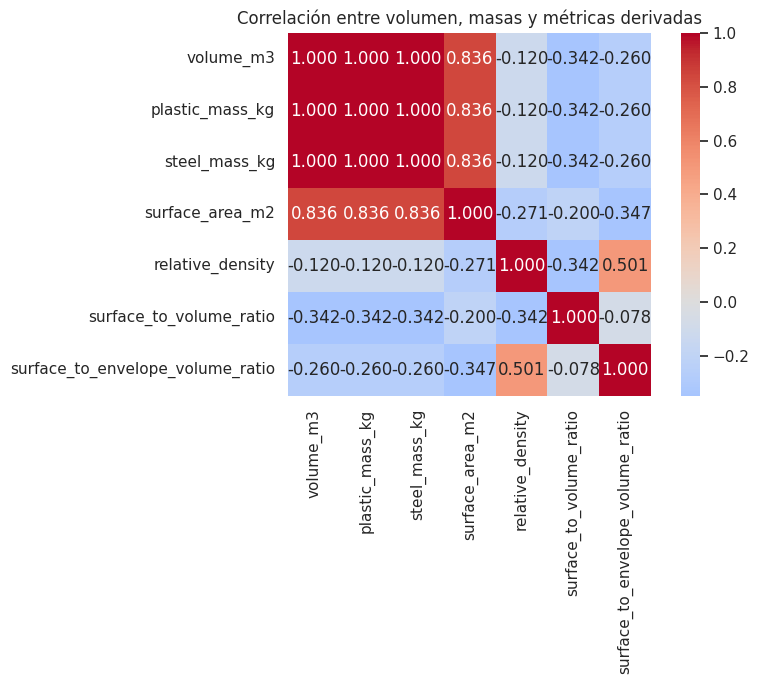

,geometry_highest_failure_pct,highest_failure_pct,best_surface_to_volume_median_geometry,best_surface_to_volume_median,best_surface_to_envelope_median_geometry,best_surface_to_envelope_median,best_porosity_median_geometry,best_porosity_median,pareto_absolute_candidate_count,pareto_normalized_candidate_count,pareto_absolute_dominant_geometry,pareto_absolute_dominant_share_pct,pareto_normalized_dominant_geometry,pareto_normalized_dominant_share_pct
0,SCHWARZ,23.456790,BCC,202.738418,BCC,23.244112,EXP,0.973680,150,107,EXP,54.000000,BCC,66.355140


In [22]:
# ============================================================
# 2A.11 Redundancia y conclusiones automáticas
# ============================================================

redundancy_cols = ["volume_m3", "plastic_mass_kg", "steel_mass_kg", "surface_area_m2", "relative_density", "surface_to_volume_ratio", "surface_to_envelope_volume_ratio"]
redundancy_cols = [c for c in redundancy_cols if c in df_viable.columns]
redundancy_corr = df_viable[redundancy_cols].corr()

display(redundancy_corr)

plt.figure(figsize=(9, 7))
if sns is not None:
    sns.heatmap(redundancy_corr, annot=True, fmt=".3f", cmap="coolwarm", center=0, square=True)
else:
    plt.imshow(redundancy_corr, cmap="coolwarm", aspect="auto")
    plt.colorbar()
plt.title("Correlación entre volumen, masas y métricas derivadas")
plt.tight_layout()
plt.savefig("outputs/figures/2A_redundancy_volume_mass_corr.png", dpi=300)
plt.show()

eda_conclusions = {}
max_failure_row = dataset_quality_summary.sort_values("failed_pct", ascending=False).iloc[0]
eda_conclusions["geometry_highest_failure_pct"] = max_failure_row["geometry"]
eda_conclusions["highest_failure_pct"] = max_failure_row["failed_pct"]

for metric, geom_key, value_key in [
    ("surface_to_volume_ratio", "best_surface_to_volume_median_geometry", "best_surface_to_volume_median"),
    ("surface_to_envelope_volume_ratio", "best_surface_to_envelope_median_geometry", "best_surface_to_envelope_median"),
    ("porosity", "best_porosity_median_geometry", "best_porosity_median")
]:
    if metric in df_viable.columns:
        s = df_viable.groupby("geometry")[metric].median().sort_values(ascending=False)
        eda_conclusions[geom_key] = s.index[0]
        eda_conclusions[value_key] = s.iloc[0]

eda_conclusions["pareto_absolute_candidate_count"] = int(pareto_abs_df["is_pareto"].sum())
eda_conclusions["pareto_normalized_candidate_count"] = int(pareto_norm_df["is_pareto"].sum())

if len(pareto_abs_geometry_summary) > 0:
    eda_conclusions["pareto_absolute_dominant_geometry"] = pareto_abs_geometry_summary.iloc[0]["geometry"]
    eda_conclusions["pareto_absolute_dominant_share_pct"] = pareto_abs_geometry_summary.iloc[0]["pareto_share_pct"]
if len(pareto_norm_geometry_summary) > 0:
    eda_conclusions["pareto_normalized_dominant_geometry"] = pareto_norm_geometry_summary.iloc[0]["geometry"]
    eda_conclusions["pareto_normalized_dominant_share_pct"] = pareto_norm_geometry_summary.iloc[0]["pareto_share_pct"]

eda_conclusions_df = pd.DataFrame([eda_conclusions])
display(eda_conclusions_df)

## Conclusiones de la Sección 2A

El EDA muestra que las familias geométricas presentan comportamientos diferentes. Schwarz es la familia con mayor porcentaje de fallas, por lo que será prioritaria para clasificación de viabilidad. BCC es muy estable y presenta buen desempeño mediano en eficiencia área/volumen. EXP destaca por su alta porosidad mediana.

Las interacciones físicas confirman que las propiedades dependen de proporciones geométricas, no solo de dimensiones absolutas. Por ello, se agregaron ratios CAD adimensionales por familia.

Los gráficos de Pareto evidencian que no existe una geometría universalmente óptima. La selección depende del criterio: masa, área superficial, porosidad, densidad relativa o eficiencia respecto al volumen envolvente.

La siguiente subsección natural es **2B — Clasificación de viabilidad geométrica**, usando solo variables CAD de entrada, particiones estratificadas y métricas adecuadas para datos desbalanceados.

In [23]:
# ============================================================
# 2A.12 Exportación final de reportes EDA
# ============================================================

eda_reports_excel_path = "outputs/tables/section2A_eda_reports_iteracion3.xlsx"
highlighted_designs_path = "outputs/tables/2A_highlighted_designs_iteracion3.xlsx"

with pd.ExcelWriter(eda_reports_excel_path, engine="openpyxl") as writer:
    dataset_quality_summary.to_excel(writer, sheet_name="DATASET_QUALITY", index=False)
    modeling_view_report_df.to_excel(writer, sheet_name="MODELING_VIEWS", index=False)
    top_correlations_df.to_excel(writer, sheet_name="TOP_CORRELATIONS", index=False)
    benchmark_summary.to_excel(writer, sheet_name="BENCHMARK_SUMMARY")
    pareto_abs_geometry_summary.to_excel(writer, sheet_name="PARETO_ABS_BY_GEOM", index=False)
    pareto_norm_geometry_summary.to_excel(writer, sheet_name="PARETO_NORM_BY_GEOM", index=False)
    redundancy_corr.to_excel(writer, sheet_name="REDUNDANCY_CORR")
    eda_conclusions_df.to_excel(writer, sheet_name="EDA_CONCLUSIONS", index=False)

with pd.ExcelWriter(highlighted_designs_path, engine="openpyxl") as writer:
    compact_design_table(top_surface_to_volume, 25).to_excel(writer, sheet_name="TOP_SURF_TO_VOLUME", index=False)
    compact_design_table(top_porosity, 25).to_excel(writer, sheet_name="TOP_POROSITY", index=False)
    compact_design_table(top_surface_to_envelope, 25).to_excel(writer, sheet_name="TOP_SURF_TO_ENVELOPE", index=False)
    compact_design_table(top_pareto_abs, 25).to_excel(writer, sheet_name="PARETO_ABSOLUTE", index=False)
    compact_design_table(top_pareto_norm, 25).to_excel(writer, sheet_name="PARETO_NORMALIZED", index=False)

print("Reportes EDA exportados:")
print(eda_reports_excel_path)
print(highlighted_designs_path)

Reportes EDA exportados:
outputs/tables/section2A_eda_reports_iteracion3.xlsx
outputs/tables/2A_highlighted_designs_iteracion3.xlsx
